In [1]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itables import show
import time as tm
import random as rd

from src.A_Data_analysis import fleet_analysis
from src.A_Data_analysis import assignment_analysis
from src.A_Data_analysis import productivity_analysis
from src.B_Model_fitting import retirement_prio
from src.B_Model_fitting import assignment_multilogit
from src.B_Model_fitting import productivity_causality
from src.C_Modelling import productivity_modelling
from src.C_Modelling import global_modelling
from src.C_Modelling import fleet_content_modelling
from src.Common_tools import vis_ref

importlib.reload(vis_ref)
importlib.reload(fleet_analysis)
importlib.reload(assignment_analysis)
# importlib.reload(productivity_analysis)
importlib.reload(retirement_prio)
importlib.reload(assignment_multilogit)
importlib.reload(productivity_causality)
# importlib.reload(productivity_modelling)
importlib.reload(global_modelling)

['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']
['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\p.viry\\AppData\\Local\\Programs\\Python\\Python313', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv', '', 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Lib\\site-packages']
['C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\.venv\\Scripts\\python313.zip', 'C:\\Users\\p.viry\\AppData\\Local\\Pro

<module 'src.C_Modelling.global_modelling' from 'C:\\Users\\p.viry\\PycharmProjects\\Thesis_models\\src\\C_Modelling\\global_modelling.py'>

# Fleet renewal

## Loading data

In [3]:
#calibration_am
db_full = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet//fleet_data_calibration_am.csv')
db_full.drop(columns=['Unnamed: 0'], inplace = True)
y_min = db_full['Year Built'].min()
db_full['Year Built'] =  (db_full['Year Built'] - y_min).astype(int)
db_selec = db_full.rename(columns={'Date':'Event Date', 'Year Built':'Delivery Date'})
db_selec = db_selec[(db_selec['Delivery Date']<=2019-y_min)&(db_selec['Delivery Date']>1979-y_min)] #40 yo max to avoid outliers effects
y_min = db_selec['Delivery Date'].min()
db_selec['Delivery Date'] =  (db_selec['Delivery Date'] - y_min).astype(int)
retired_not_considered = ['CRJX','A20N', 'B748', 'A339', 'B77L','B38M']
db_selec = db_selec[~db_selec['Aircraft Type'].isin(retired_not_considered)]

In [2]:
db_full = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_treated_final.xlsx')
# db_full['Aircraft Type'] = (db_full['Type'].astype(str)+db_full['Model'].astype(str)) #version plus détaillée.
db_full.rename(columns = {'Type':'Aircraft Type'}, inplace = True)
### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = db_full[['Aircraft Type','Engine', 'Delivery Date', 'Status', 'Date']].rename(columns={'Date':'Event Date'})

In [6]:
#experiment with icao nomenclature directly, nécessite charger des éléments avant.
taa_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/aircraft_codes_taa_icao.csv', sep =';')
dico_taa_icao = dict(zip(list(taa_ICAO_names['Aircraft Type']), list(taa_ICAO_names['ICAO_Code'])))
df_ac_taa = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_250610.xlsx')[['MSN','Type','Model','Exp. Delivery','Year Built','Status','Date']]
df_ac_taa['Year Built']= df_ac_taa['Year Built'].fillna(df_ac_taa['Exp. Delivery'])
df_ac_taa = df_ac_taa[df_ac_taa['Year Built']!='12/30/1899']
df_ac_taa = df_ac_taa[~df_ac_taa['Year Built'].isna()]
df_ac_taa['Year Built'] = df_ac_taa['Year Built'].apply(vis_ref.date_to_float_year)
df_ac_taa['Date'] = df_ac_taa['Date'].apply(vis_ref.date_to_float_year)

df_ac_taa['Aircraft Type'] = df_ac_taa['Type'] + df_ac_taa['Model'].astype(str)
df_ac_taa['Aircraft Type'] = df_ac_taa['Aircraft Type'].map(dico_taa_icao)
df_ac_taa.drop(columns =['Type', 'Model','MSN','Exp. Delivery'], inplace = True)
df_ac_taa = df_ac_taa[df_ac_taa['Year Built']<2025]
df_ac_taa.reset_index(drop = True, inplace = True)
# ids_taa =sorted(list(df_ac_taa_a['Aircraft Type'].unique()))
df_ac_taa = df_ac_taa[df_ac_taa['Aircraft Type'].isin(ids_bts)]
dico2 = dict(zip(modeled_aircraft['ICAO Name'],modeled_aircraft.index))
dico2_inv = {v: k for k, v in dico2.items()}
df_ac_taa['Aircraft Type'] = df_ac_taa['Aircraft Type'].map(dico2)
y_min = df_ac_taa['Year Built'].min()
df_ac_taa['Year Built'] =  (df_ac_taa['Year Built'] - y_min).astype(int)
n_y_f = df_ac_taa['Year Built'].max()+1

### Possibility to add filters on the aircraft size, aircraft model, etc...
db_selec = df_ac_taa[['Aircraft Type', 'Year Built', 'Status', 'Date']].rename(columns={'Date':'Event Date', 'Year Built':'Delivery Date'})

NameError: name 'ids_bts' is not defined

## Data analysis

In [10]:
fleet_analysis.visu_fleet(db_selec)

In [15]:
for a in range(2000,2024):
    for b in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
        t=a+b
        mask = ((db_selec['Status']=='Active')|(db_selec['Event Date']>t))&(db_selec['Delivery Date']<a+1)
        fleet_analysis.visu_prod(db_selec[mask], reso = 1, title = 'fleet_produced_active_'+str(t+0.0), xmax = t-0.9)

In [16]:
from PIL import Image
import os

def folder_to_gif(folder_path, output_path="output.gif", duration=50, loop=0):
    valid_ext = (".png", ".jpg", ".jpeg", ".bmp", ".webp")

    files = sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith(valid_ext)
    ])

    if not files:
        raise ValueError("Aucune image trouvée dans le dossier.")

    images = [Image.open(f).convert("RGB") for f in files]

    images[0].save(
        output_path,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=loop
    )

    print(f"GIF sauvegardé : {output_path}")
folder_to_gif('figures/fleet_figures/gif_factory')

GIF sauvegardé : output.gif


In [35]:
fleet_analysis.visu_retirements(db_selec, reso_1 = 1, reso_2 = 3)

## Model training

In [3]:
db_r = fleet_analysis.retirement_ranking(db_selec)

0: -6.762, -6.1892, -6.1076, -5.9847, -5.9465, -5.9044, -5.8861, -5.8642, -5.8467, -5.842, -5.8274, -5.812, reduction needed
-5.8047, -5.7997, -5.796, -5.7904, -5.7874, -5.7834, -5.7815, -5.7794, -5.7776, -5.7747, -5.7734, -5.7718, -5.7706, 
1: -5.7704, -5.7692, -5.7681, -5.767, -5.766, -5.7645, -5.7637, -5.7593, reduction needed
-5.7579, -5.7574, -5.7569, -5.7563, -5.7559, -5.7534, reduction needed
-5.751, -5.7506, -5.7504, -5.7502, -5.75, -5.7499, -5.7497, -5.7496, -5.7494, -5.7493, -5.7491, 
2: -5.7491, -5.749, -5.7489, -5.7488, -5.7486, -5.7485, -5.7484, -5.7483, -5.7482, -5.7481, -5.748, -5.7479, -5.7478, -5.7476, -5.746, reduction needed
-5.7454, -5.7453, -5.7453, -5.7453, -5.7452, -5.7452, -5.7451, -5.7451, -5.7451, -5.745, 
3: -5.745, -5.745, -5.7449, -5.7449, -5.7449, -5.7448, -5.7448, -5.7448, -5.7447, -5.7447, -5.7447, -5.7446, -5.7434, reduction needed
-5.7433, -5.7432, reduction needed
-5.7432, -5.7432, -5.7431, reduction needed
-5.7431, -5.7431, -5.743, reduction needed
-

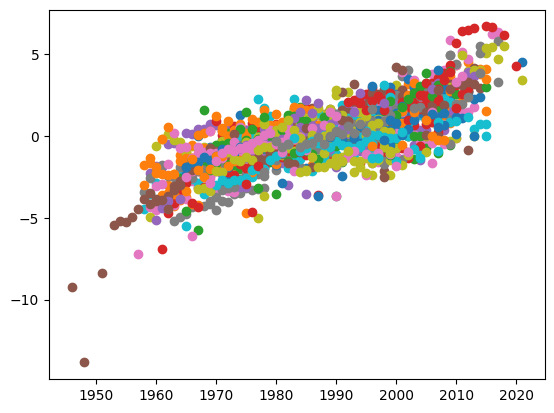

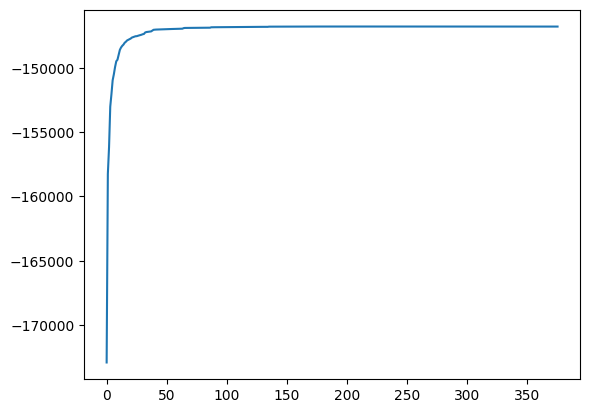

In [48]:
df_stat = retirement_prio.setting_df(db_r)

# initial 
stats, y_lims, list_mod = retirement_prio.fit_type_y(df_stat, epoch=10, rep = 25)

#avec chargement du résultat précédent
# stats, y_lims, list_mod = retirement_prio.load_prop(title = 'TAA_propension_bts')
# stats = np.where(np.isnan(stats),0, stats)#au cas ou on itère!
# stats, y_lims, list_mod = retirement_prio.fit_type_y(df_stat, epoch=10, rep = 30, vals = stats.T)

retirement_prio.save_prop(stats.transpose(),list_mod,y_lims, title = 'TAA_propension_bts')

0: -6.7644, -6.5042, -6.2881, -6.1187, -5.995, -5.9131, -5.8657, -5.8448, -5.842, -5.8499, -5.8624, -5.875, -5.8847, -5.8899, -5.8898, -5.8846, -5.8748, -5.8613, -5.8454, -5.8283, -5.8111, -5.7949, -5.7807, -5.769, -5.7602, -5.7543, -5.7509, -5.7496, -5.7497, -5.7503, 
1: -5.7502, -5.7507, -5.7506, -5.7494, -5.7472, -5.7439, -5.7399, -5.7355, -5.731, -5.7269, -5.7233, -5.7203, -5.7181, -5.7166, -5.7155, -5.7148, -5.7142, -5.7136, -5.7129, -5.712, -5.7109, -5.7097, -5.7083, -5.7068, -5.7054, -5.704, -5.7029, -5.7019, -5.701, -5.7004, 
2: -5.7004, -5.6998, -5.6993, -5.6988, -5.6983, -5.6978, -5.6972, -5.6966, -5.6959, -5.6953, -5.6947, -5.6941, -5.6935, -5.6931, -5.6926, -5.6922, -5.6919, -5.6915, -5.6911, -5.6908, -5.6904, -5.69, -5.6897, -5.6893, -5.689, -5.6886, -5.6883, -5.688, -5.6877, -5.6874, 
3: -5.6874, -5.6872, -5.6869, -5.6866, -5.6864, -5.6861, -5.6859, -5.6856, -5.6854, -5.6852, -5.685, -5.6847, -5.6845, -5.6843, -5.6841, -5.6839, -5.6838, -5.6836, -5.6834, -5.6832, -5.6831,

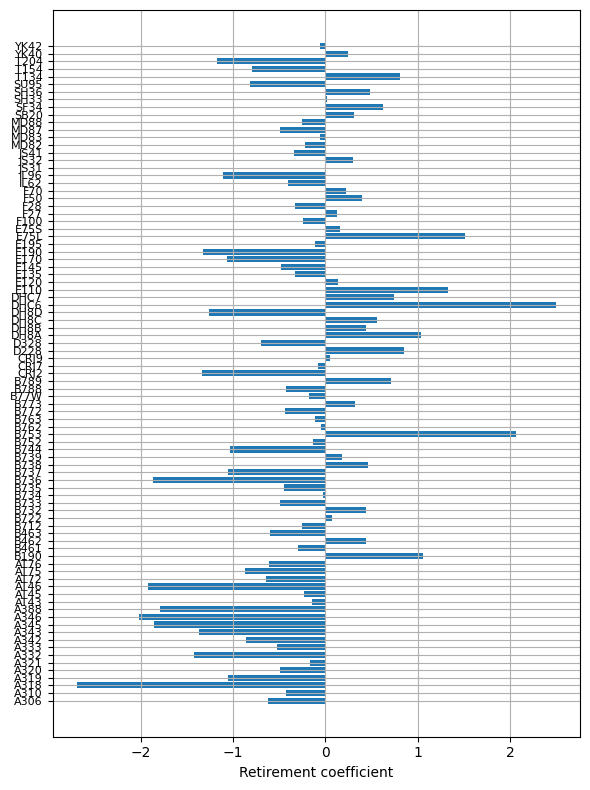

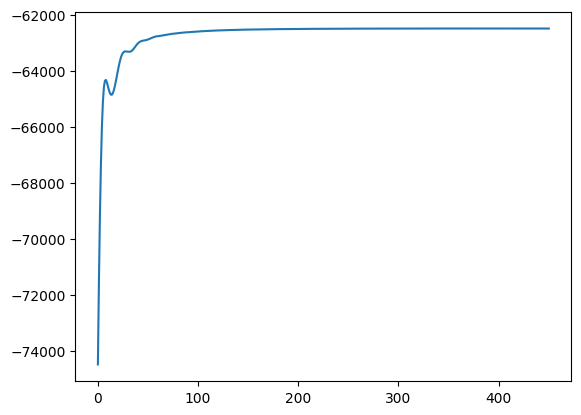

0.18959862557460871


In [4]:
df_stat_lin = retirement_prio.setting_df_lin(db_r)
# vals, beta, list_mod = retirement_prio.load_prop_lin(title = 'TAA_propension_lin_icao_am')
# vals = np.where(np.isnan(vals),0, vals)#au cas ou on itère!
list_types = sorted(df_stat_lin['Aircraft Type'].unique())
dico2 = dict(zip(list_types,np.arange(len(list_types))))
dico2_inv = {v: k for k, v in dico2.items()}
df_stat_lin['Aircraft Type'] = df_stat_lin['Aircraft Type'].map(dico2)
vals, beta, list_mod = retirement_prio.fit_type_y_lin(df_stat_lin, epoch=15, rep = 30, vals= None,
                                                        beta = None,dico2_inv = dico2_inv, n_ac = None)
retirement_prio.save_prop_lin(vals.transpose(),beta,[dico2_inv[u] for u in list_mod], title = 'TAA_propension_lin_icao_am')
print(beta)

In [5]:
# stats, beta, list_mod = retirement_prio.load_prop_lin(title = 'TAA_propension_lin_icao_am')
# print(beta)

0.1857285311230981


# Aircraft productivity

## Loading data

In [3]:
individual_stops = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_ind_anal.csv')
individual_stops.drop(columns=['Unnamed: 0.1', 'Unnamed: 0','Taille_f', 
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
individual_stops.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                 'ADES_nf': 'ADES +1', 'ADEP_nf' : 'ADEP +1', 'ADEP_pf': 'ADEP -1', 'ADES_pf': 'ADES -1',
                                'echantillon':'Period','time_delta': 'Real Flight Duration', 'time_delta2':'Planned Flight Duration',
                                'time_delta_nf': 'Real Flight Duration +1', 'time_delta2_nf':'Planned Flight Duration +1',
                                 'time_delta_pf': 'Real Flight Duration -1', 'time_delta2_pf':'Planned Flight Duration -1',
                                 'delta_flights' : 'Ground Time', 'delta_pre_flights' : 'Ground Time -1'}, inplace = True)

#standards correction eurocontrol pour mettre des GTs
# individual_stops['Planned Flight Duration +1'] = individual_stops['Planned Flight Duration +1']+0.1
# individual_stops['Ground Time'] = individual_stops['Ground Time']-0.1
# individual_stops['Planned Flight Duration -1'] = individual_stops['Planned Flight Duration -1']+0.1
# individual_stops['Ground Time -1'] = individual_stops['Ground Time -1']-0.1

In [2]:
flights_streaks = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_long_anal.csv')
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['FILED OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['FILED ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED OFF BLOCK TIME'] = pd.to_datetime(flights_streaks['ACTUAL OFF BLOCK TIME'], utc=True).dt.tz_localize(None)
flights_streaks['FILED ARRIVAL TIME'] = pd.to_datetime(flights_streaks['ACTUAL ARRIVAL TIME'], utc=True).dt.tz_localize(None)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator',
                                'AC Registration':'Aircraft Registration', 'echantillon':'Period'}, inplace = True)

In [7]:
flights_streaks= flights_streaks[flights_streaks['echantillon']<20]
print(flights_streaks[flights_streaks['Actual Distance Flown (nm)']<1500/1.852].shape)
print(flights_streaks[flights_streaks['Actual Distance Flown (nm)']>4000/1.852].shape)
print(flights_streaks[(flights_streaks['Actual Distance Flown (nm)']>1500/1.852)&(flights_streaks['Actual Distance Flown (nm)']<4000/1.852)].shape)
print(flights_streaks[['Actual Distance Flown (nm)','AC Registration','echantillon']].groupby(['AC Registration','echantillon']).count().shape)
print(flights_streaks[['Actual Distance Flown (nm)','AC Registration']].groupby(['AC Registration']).count().shape)
flights_streaks.drop(columns=['Unnamed: 0.2','Unnamed: 0.1', 'Unnamed: 0','Taille_f', 'ADES_nf', 'ADEP_nf',
                              'ADEP_pf', 'ADES_pf','time_delta','time_delta2', 'time_delta_nf', 'time_delta2_nf',
                                 'time_delta_pf', 'time_delta2_pf','delta_flights' , 'delta_pre_flights',
                               'Siege_ADES', 'Siege_ADEP', 'Siege', 'Tot siege', 'mean_distance','Actual Distance Flown (nm)'],
                     inplace = True)
flights_streaks.rename(columns={'AC Type': 'Aircraft Type', 'AC Operator':'Aircraft Operator','AC Registration':'Aircraft Registration',
                                'echantillon':'Period'}, inplace = True)

(5639644, 32)
(415021, 32)
(1718777, 32)
(58177, 1)
(4752, 1)


## Data visualisation individual stops

In [43]:
productivity_analysis.GT_density(individual_stops, FT_min = 0.5, name_fig = 'GT_density_3',sigma = 0.005, reso = 1000)

In [42]:
productivity_analysis.TATs_matrix(individual_stops, x_min = 0.5, y_min = 0.5, name_fig= 'Full_df2', reso = 1000, sigma = 0.015)

5.4% are not b&f flights


## Data visualisation flight streaks

In [26]:
aircraft_ex = flights_streaks[(flights_streaks['Aircraft Registration']=='FGKXY')&(flights_streaks['Period']==17)] #B77w
x_min = productivity_analysis.visu_distrib(aircraft_ex, titre = 'hour_distrib_A320', visu = True, visu_c = True)[0]
productivity_analysis.visu(aircraft_ex, titre = 'A320', visu = True, x_min = x_min)


In [10]:
L_NB = ['B738', 'A320', 'A319', 'A20N', 'A321', 'A21N', 'B38M', 'B752','B737',  'B739','A318',
        'B712','B733','B736','B735','B753','MD11','MD82','B39M','B734'] #NB classiques
LC = ['RYR', 'EZY', 'WZZ', 'VLG']
LL = ['AFR', 'KLM', 'BAW', 'DLH', 'SAS', 'TAP', 'IBE', 'SWR']
selec = flights_streaks[(flights_streaks['Aircraft Type'].isin(L_NB))&(flights_streaks['Period']<20)&((flights_streaks['Period']%4==1)|(flights_streaks['Period']%4==2))]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_hs2', min_fh = 0.5, 
                                          max_fh = 6,reso = 400, sigma = 0.02, n_s = 3)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [28]:
selec = flights_streaks[(flights_streaks['Period']<20)&(flights_streaks['Aircraft Type'].isin(['A332', 'A333']))]
# selec = flights_streaks[(flights_streaks['Period']<20)]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_a33_3', min_fh = 2, 
                                          max_fh = 14,reso = 400, sigma = 0.03, n_s = 2)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [3]:
selec = flights_streaks[(flights_streaks['Period']<20)&(flights_streaks['Aircraft Type'].isin(['B763']))]
# selec = flights_streaks[(flights_streaks['Period']<20)]
flight_grouping = productivity_analysis.constru_flight_streak(selec)
productivity_analysis.visu_flight_streaks(flight_grouping,title = 'regimes_b763', min_fh = 2, 
                                          max_fh = 14,reso = 400, sigma = 0.03, n_s = 2)

0%, 5%, 10%, 15%, 20%, 25%, 30%, 35%, 40%, 45%, 50%, 55%, 60%, 65%, 70%, 75%, 80%, 85%, 90%, 95%, 100%, 100 %, ok.
1, 2, 3, 4, 5, 6, 7, 8, 9, 10, ok.


In [4]:
flight_grouping_2 = flight_grouping[flight_grouping[:,1]/flight_grouping[:,3]>0]
productivity_analysis.streaks_matrix(flight_grouping_2,title = 'streak_matrix_b763', min_fh = 0.5, 
                                          max_fh = 14,reso = 1000, sigma = 0.02)

## Model training

Mean Squared Error: 11.920657769646272
R-squared: 0.03828387645108433


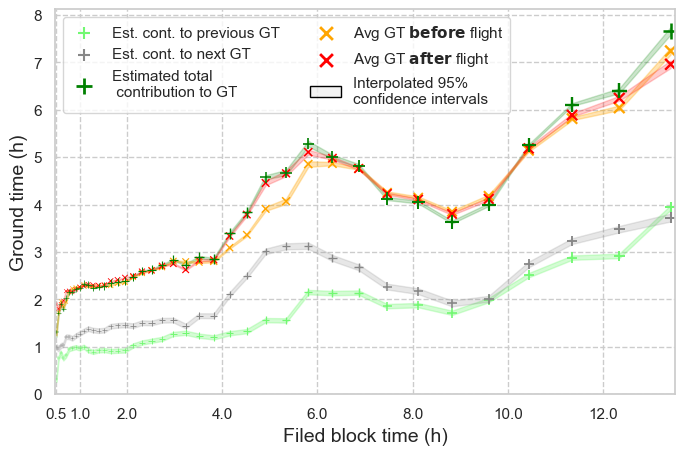

In [12]:
# individual_stops_reg = individual_stops[(individual_stops['Period']<20)&((individual_stops['Period']%4==1)|(individual_stops['Period']%4==2))]
individual_stops_reg = individual_stops[(individual_stops['Period']<20)]
productivity_causality.tat_reg(individual_stops_reg, 'EC_preCOVID', reso = 40)

#La suite ?

# Assignment on routes

## Loading data

#### BTS

In [2]:
y_min = 1990 #1990 , normalement
y_max = 2025 #pour le modèle entraîné

bts_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Travail de Tobias\Technical Data Aircrafts//aircraft_codes_icao_joined.csv', sep = ';')
print('If one wishes to merge bts and ec, then it requires, ec formalism (less strict), and identifying the type with the ICAO_Code, not Description')
bts_ICAO_names.rename(columns = {'AIRCRAFT_TYPE' : 'Aircraft Type','Description':'Aircraft Type Name'}, inplace = True)
bts_ICAO_names['Aircraft Type'] = bts_ICAO_names['Aircraft Type'].astype(str)

traff_1 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y_min) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
for y in range(y_min+1, y_max+1):
    if y%5 == 0 :
        print(y)
    df = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts\data_full_airlines\\' + str(y) + '\T_T100_SEGMENT_ALL_CARRIER.csv')
    traff_1 = pd.concat([traff_1, df], ignore_index=True)

traff_1.rename(columns = {'ORIGIN_AIRPORT_ID' : 'ADEP','DEST_AIRPORT_ID': 'ADES', 'YEAR':'Period', 'DEPARTURES_PERFORMED': 'N_flights','DISTANCE':'Distance',
                          'AIRCRAFT_TYPE': 'Aircraft Type', 'UNIQUE_CARRIER' : 'Aircraft Operator','UNIQUE_CARRIER_NAME':'Aircraft Operator Name', 'SEATS': 'Seats'}, inplace = True)  
traff_1['Aircraft Type'] = traff_1['Aircraft Type'].astype(str)
bts_ICAO_names = bts_ICAO_names.drop(columns=['Aircraft Type Name']).rename(columns ={'ICAO_Code':'Aircraft Type Name'}) #ligne pour l'analyse directe ICAO
traff_1 = pd.merge(traff_1, bts_ICAO_names[['Aircraft Type', 'Aircraft Type Name']], on = ['Aircraft Type'])

If one wishes to merge bts and ec, then it requires, ec formalism (less strict), and identifying the type with the ICAO_Code, not Description
1995
2000
2005
2010
2015
2020
2025


152 152
new seats, ok
Poids
synthesis...


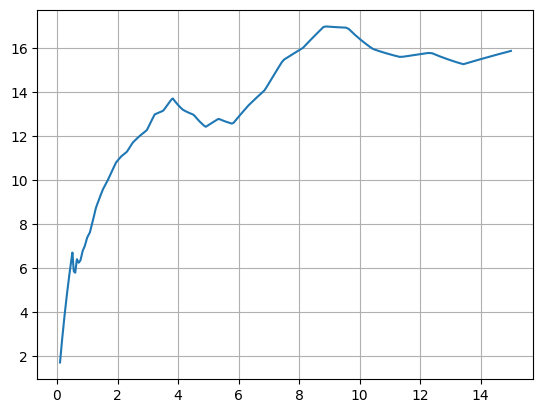

ok


In [3]:
### Version seats équivalents écos, pour les scénarios
main_Aircrafts = ['B738', 'A320', 'A319', 'A20N', 'A321', 'A21N', 'B38M', 'AT76', 'E190',
       'B77W', 'B789', 'A333', 'E195', 'CRJ9', 'AT75', 'DH8D', 'BCS3', 'A332','A338',
       'B788', 'A359', 'B77L', 'DH8A', 'B763', 'B734', 'B772', 'CRJX', 'B752',
       'C56X', 'B737', 'S92', 'B739', 'B744', 'E55P', 'E75L', 'SU95', 'A388',
       'AT72', 'E145', 'E170', 'A306', 'AT45', 'E295', 'SF34', 'B748', 'A318',
       'C25A', 'A339', 'F2TH', 'B733', 'C68A', 'CL35', 'E35L', 'A35K', 'E75S',
       'E290', 'PC12', 'GLEX', 'C510', 'C525', 'DH8B', 'B78X', 'A343', 'CRJ2',
       'BE20', 'BCS1', 'CL60', 'PC24', 'C25B', 'A139', 'AT43',
        'B736','B735', 'RJ1H','B712', 'SB20','F100','A346','CRJ7','H25B',
          'B753','B762','B764','F50','JS41','ATP' , 'DH8C',
        'D328', 'A310','MD11','C680','JS32','MD81','MD82','MD88','FA7X','J328',
        'BE40','D228','CL30','C550','E120','SW4',
         'E135', 'E50P','GLF5','L410','F900','AT46','C650',
        'LJ60','B463','DHC6','B39M','B742', 'B773', 'A30B', 'F70',
         'MD87','B722','B732','DC93','B743', 'DC10',
        'L101','B741','DC95','MD90','A342','CRJ1',
        'B721','DC94', 'B74D', 'C208','C402', 'A345',
        'B703', 'B74S','C212', 'AJ27', 'C919', 'CVLT', 'E110',
        'F27', 'F28','L188','DC86', 'DC87','DC91','DC92',
        'SH33','SH36'] #115 avions, 98% des vols

Appr_max_seats = [190, 180, 145, 194, 228, 244, 200, 78, 100,
            550, 406, 440, 146, 90, 78, 78, 160, 406,406,
            359, 440, 440, 40, 350, 188, 440, 100, 240,
            9, 150, 24, 217, 660, 10, 80, 103, 853, #A380
            78, 50, 70, 274, 50, 146, 36, 605, 132,
            10, 440, 19, 148, 9, 12, 37, 480, 76, #E75S
            100, 8, 18, 5, 6, 40, 440, 375, 50,
            10, 135, 30, 10, 10, 15, 48,
            140, 132, 100, 134, 58, 109, 440, 68, 9,#H25B
            290, 290, 375, 56, 30, 68, 56,
            30, 280, 380, 11, 19, 172, 172, 172, 19, 43, #J328
             4, 19, 16, 8, 30, 19, 
               37, 7, 14, 19, 19, 48, 15, #C650
              8, 100, 20, 240, 480, 550, 345,70,
            140, 189, 130, 127, 608, 380, #DC10
            315, 480,127, 187, 375, 52, 
            189, 127, 200, 14, 10, 375, #A345
            200, 400, 26, 90, 190, 52, 18,
            56, 80, 98, 270, 270,90,90, #DC92
             33,39 ] #configurations denses en classe éco.
print(len(main_Aircrafts), len(Appr_max_seats))
sizes_ac =dict(zip(main_Aircrafts,Appr_max_seats))

mask = traff_1['Aircraft Type Name'].isin(sizes_ac)
traff_1.loc[mask, 'Seats'] = traff_1.loc[mask, 'Aircraft Type Name'].map(sizes_ac)*traff_1.loc[mask, 'N_flights']
print('new seats, ok')
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1 = traff_1[traff_1['N_flights']>0]
traff_1['Distance'] = traff_1['Distance']*1.852
traff_1 = traff_1[traff_1['Distance']>80] #filtres sur le noùbre de km
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
traff_1.drop(columns=['PASSENGERS'], inplace = True)
print('Poids')
airports = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts//T_MASTER_CORD.csv')[['AIRPORT_ID','AIRPORT_COUNTRY_NAME']]
airports_us = airports[airports['AIRPORT_COUNTRY_NAME']=='United States']
airports_not_us = airports[airports['AIRPORT_COUNTRY_NAME']!='United States']
us_id = airports_us['AIRPORT_ID'].unique() #contient porto rico et des iles
not_us_id = airports_not_us['AIRPORT_ID'].unique() #contient porto rico et des iles (priorité aux us)
# print(traff_1.shape,traff_1['ADES'].isin(us_id).sum()+(traff_1['ADES'].isin(not_us_id)&(~traff_1['ADES'].isin(us_id))).sum()) #ok à quelques vols près
traff_1['Weight']= 0
traff_1.loc[traff_1['ADES'].isin(us_id), 'Weight']+=0.5
traff_1.loc[traff_1['ADEP'].isin(us_id), 'Weight']+=0.5
traff_1 = assignment_analysis.agg_ind_1(traff_1) 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='ASK') 
productivity_modelling.activity_assignment(traff_1, 'EC_preCOVID')
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='Av_ac_seats') 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='N_flights') 
traff_1['Aircraft Type'] = traff_1['Aircraft Type Name'] #synthèse des id ICAO
print('ok')

In [11]:
### attribution type TP, NB, RJ, WB
TP = ['C206', 'C208','C180', 'PA18', 'PA31','BE20', 'COUR',
       'C212', 'C172','C185','PA32', 'DHC2', 'GA8','PA23',
      'PC12','C402','AA1','BN2P', 'DHC3','B190','G115', 'AC90',
     'DHC6','DH8A', 'D328','SB20', 'AT43','AT72', 'DH8D','J328',
     'CVLP', 'SW4']
RJ = ['LJ60', 'CL30','C500','CL60','F2TH','C750','GLF4','GL6T'
     'C56X', 'GALX', 'H25B', 'C680','GLF6', 'F7X','E35L','LJ45',
     'G150','E600','GLF5','GL5T','FA8X','F900','GLEX','E135','FA6X',
     'GLF7','GA5C','CRJ2', 'E190', 'E145','CRJ7', 'E170', 'E75L', 'CRJ9',
     'E195', ]
NB = ['B733', 'BCS1','B737', 'A319', 'B752','B732', 'A21N', 'A320',
     'B738','A321', 'B712', 'B736', 'BCS3','B734', 'MD87', 'B38M', 'B39M',
     'B739', 'A20N', 'B753',]
WB = ['B744','B789','A332', 'A30B', 'B762', 'B763',  'A339', 'B772', 
     'A333', 'B788', 'A343', 'B764', 'A359', 'B77W', 'B78X',
     'A346', 'A35K', 'B748', 'A388', 'B742']

dictionnaire_cat = {code: 'TP' for code in TP}
dictionnaire_cat.update({code: 'RJ' for code in RJ})
dictionnaire_cat.update({code: 'NB' for code in NB})
dictionnaire_cat.update({code: 'WB' for code in WB})

traff_1['Aircraft Type'] = traff_1['Aircraft Type Name'].map(dictionnaire_cat)
traff_1['Aircraft Type Name'] = traff_1['Aircraft Type Name'].map(dictionnaire_cat)


Poids
synthesis...


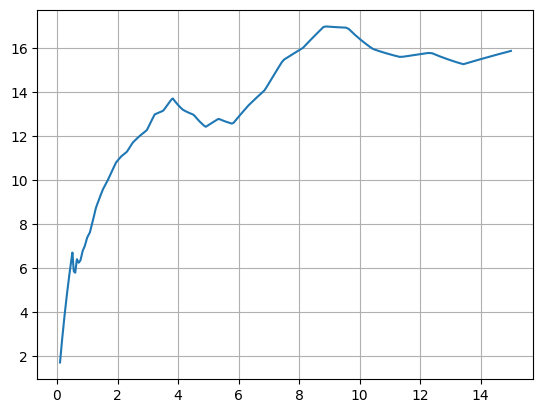

ok


In [3]:
### Version classique, pour des observations
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1 = traff_1[(traff_1['Seats']>0)]
traff_1 = traff_1[traff_1['N_flights']>0]
traff_1['Distance'] = traff_1['Distance']*1.852
traff_1 = traff_1[traff_1['Distance']>100] #filtres sur le noùbre de km
traff_1['ADEP Name'] = traff_1['ADEP'] #a adapter bien sur
traff_1['ADES Name'] = traff_1['ADES'] #a adapter bien sur
traff_1.drop(columns=['PASSENGERS'], inplace = True)
print('Poids')
airports = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\data_planes_bts//T_MASTER_CORD.csv')[['AIRPORT_ID','AIRPORT_COUNTRY_NAME']]
airports_us = airports[airports['AIRPORT_COUNTRY_NAME']=='United States']
airports_not_us = airports[airports['AIRPORT_COUNTRY_NAME']!='United States']
us_id = airports_us['AIRPORT_ID'].unique() #contient porto rico et des iles
not_us_id = airports_not_us['AIRPORT_ID'].unique() #contient porto rico et des iles (priorité aux us)
# print(traff_1.shape,traff_1['ADES'].isin(us_id).sum()+(traff_1['ADES'].isin(not_us_id)&(~traff_1['ADES'].isin(us_id))).sum()) #ok à quelques vols près
traff_1['Weight']= 0
traff_1.loc[traff_1['ADES'].isin(us_id), 'Weight']+=0.5
traff_1.loc[traff_1['ADEP'].isin(us_id), 'Weight']+=0.5
traff_1 = assignment_analysis.agg_ind_1(traff_1) 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='ASK') 
productivity_modelling.activity_assignment(traff_1, 'EC_preCOVID')
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='Av_ac_seats') 
traff_1 = assignment_analysis.agg_ind_s(traff_1, observation ='N_flights') 
print('ok')

### Eurocontrol

synthesis...


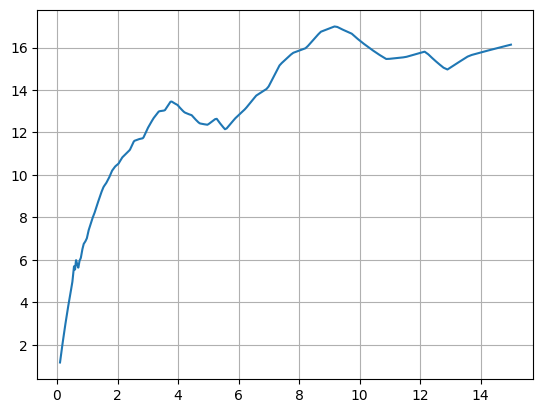

In [8]:
traff_2 = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\eurocontrol data_archive//flights_market_an_agg.csv')
traff_2.drop(columns=['Unnamed: 0','Siege_ADES', 'Siege_ADEP', 'Siege'], inplace = True)
traff_2['mean_distance'] = traff_2['mean_distance']*1.852
traff_2.rename(columns ={'AC Type':'Aircraft Type', 'AC Operator':'Aircraft Operator', 'echantillon':'Period', 
                         'Taille_f':'Seats', 'tau':'Weight', 'mean_distance':'Distance'}, inplace = True)
traff_2['ADEP Name']=traff_2['ADEP']
traff_2['ADES Name']=traff_2['ADES']
traff_2['Aircraft Type Name']= traff_2['Aircraft Type']
traff_2['Aircraft Operator Name']=traff_2['Aircraft Operator']
traff_2 = assignment_analysis.agg_ind_1(traff_2) 
traff_2 = assignment_analysis.agg_ind_s(traff_2, observation ='ASK') 
traff_2['Seats_conn_p'] = traff_2['Seats_conn_p']*12
traff_2['ASK_conn_p'] = traff_2['ASK_conn_p']*12
productivity_modelling.activity_assignment(traff_2, 'EC_preCOVID2', act=False)
traff_2 = assignment_analysis.agg_ind_s(traff_2, observation ='Av_ac_seats')

## Data visualisation (#peut être à revoir pour séparer les densités d'affichage de la fréquentation par connection)

In [9]:
assignment_analysis.market_vis(traff_2[traff_2['Period'].isin([16,17,18,19])], name_fig = 'Eurocontrol_2019_act_w2',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'Av_ac_seats', dist_limits = [2.5e2, 1.6e4], 
                                  capac_limits = [4.9e3, 4.9e6], n_market = 19, weight = True)
# traff_2.loc[traff_2['Period'].isin([17,18]),'Period'] = -1
# traff_2.loc[traff_2['Period'].isin([16,19]),'Period'] = -2
# ####on corrige un facteur 6 dans les tailles de graphe
# assignment_analysis.dynamic_market_vis(traff_2, [-1,-2],name_periods = ['Summer 2019', 'Winter 2019'], video_name = 'test_market_Type',reso = 300, smooth_param = 0.05, 
#                                   market = 'Aircraft Type', observation = 'ASK', dist_limits = [2.5e2, 1.6e4], period_ref = -2,
#                                   capac_limits = [4.9e3, 4.9e6], n_market = 16, format_v='video', period_duration = 1, weight = True)

chelou rank none


In [9]:
traff_t = traff_1.copy()
FB_seymm = pd.read_csv('D:/p.viry/Documents/Travail_recherche/Data/FB models ext/ac_model_coefficients.csv', sep=';')
line_ref = FB_seymm[FB_seymm['ac_code_icao']=='A30B']
line_742 = line_ref.copy()
line_742['ac_code_icao'] = 'B742'
line_dc10 = line_ref.copy()
line_dc10['ac_code_icao'] = 'DC10'
FB_seymm = pd.concat([FB_seymm,line_742], ignore_index=True)
FB_seymm = pd.concat([FB_seymm,line_dc10], ignore_index=True)
FB_seymm = FB_seymm[FB_seymm['ac_code_icao'].isin(list(traff_t['Aircraft Type Name'].unique()))].drop(columns = ['Unnamed: 0'])
traff_t = traff_t[traff_t['Aircraft Type Name'].isin(list(FB_seymm['ac_code_icao'].unique()))]

FB_seymm.reset_index(inplace = True)
FB_seymm.drop(columns = ['index'], inplace = True)
FB_seymm['index'] =FB_seymm.index
fb_ini = FB_seymm[['reduced_fuel_a1','reduced_fuel_a2', 'reduced_fuel_intercept']].values
dico_seymm = FB_seymm.set_index('ac_code_icao')['index'].to_dict()
global_modelling.fuel_calculations(traff_t, None, dico_seymm, fb_ini, n_flights = False)

traff_t = assignment_analysis.agg_ind_s(traff_t, observation ='FB') 
assignment_analysis.market_vis(traff_t[traff_t['Period'].isin([2025])], name_fig = 'market_bts_2025_fb_w',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation =  'FB', dist_limits = [3e2, 2.05e4], 
                                  capac_limits = [5e3, 3.1e6], n_market = 33, period_duration = 1, weight = True, format_fig='png',
                               label_size_param = 1.8)
# assignment_analysis.market_vis(traff_t[traff_t['Period'].isin([2024])], name_fig = 'market_bts_ask_w_2024',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 2.1e4], 
#                                   capac_limits = [4e3, 6e6], n_market = 24, period_duration = 1, weight = True)
# assignment_analysis.market_vis(traff_t[traff_t['Period'].isin([2024])], name_fig = 'market_bts_av_seats_w_2024',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'Av_ac_seats', dist_limits = [1.5e2, 2.1e4], 
#                                   capac_limits = [4e3, 6e6], n_market = 24, period_duration = 1, weight = True)
# assignment_analysis.market_vis(traff_t[traff_t['Period'].isin([2015])], name_fig = 'market_bts_fb_w_2015',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'FB', dist_limits = [1.5e2, 2.1e4], 
#                                   capac_limits = [4e3, 6e6], n_market = 24, period_duration = 1, weight = True)
# assignment_analysis.market_vis(traff_t[traff_t['Period'].isin([2015])], name_fig = 'market_bts_ask_w_2015',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 2.1e4], 
#                                   capac_limits = [4e3, 6e6], n_market = 24, period_duration = 1, weight = True)
# assignment_analysis.market_vis(traff_t[traff_t['Period'].isin([2015])], name_fig = 'market_bts_av_seats_w_2015',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'Av_ac_seats', dist_limits = [1.5e2, 2.1e4], 
#                                   capac_limits = [4e3, 6e6], n_market = 24, period_duration = 1, weight = True)
# assignment_analysis.dynamic_market_vis(traff_t, [i for i in range(2015,2025)], video_name = 'history_US_market_fb',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'FB', dist_limits = [1.5e2, 2.1e4], period_ref = 2024,
#                                   capac_limits = [4e3, 6e6], n_market = 18, format_v='video', weight = True, frame_s = 0.5)
# assignment_analysis.dynamic_market_vis(traff_t, [i for i in range(2015,2025)], video_name = 'history_US_market_ask',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'AKS', dist_limits = [1.5e2, 2.1e4], period_ref = 2024,
#                                   capac_limits = [4e3, 6e6], n_market = 18, format_v='video', weight = True, frame_s = 0.5)
# assignment_analysis.dynamic_market_vis(traff_t, [i for i in range(2015,2025)], video_name = 'history_US_market_ask',reso = 400, smooth_param = 0.04, 
#                                   market = 'Aircraft Type', observation = 'Av_ac_seats', dist_limits = [1.5e2, 2.1e4], period_ref = 2024,
#                                   capac_limits = [4e3, 6e6], n_market = 18, format_v='video', weight = True, frame_s = 0.5)

chelou rank none


ZeroDivisionError: float division by zero

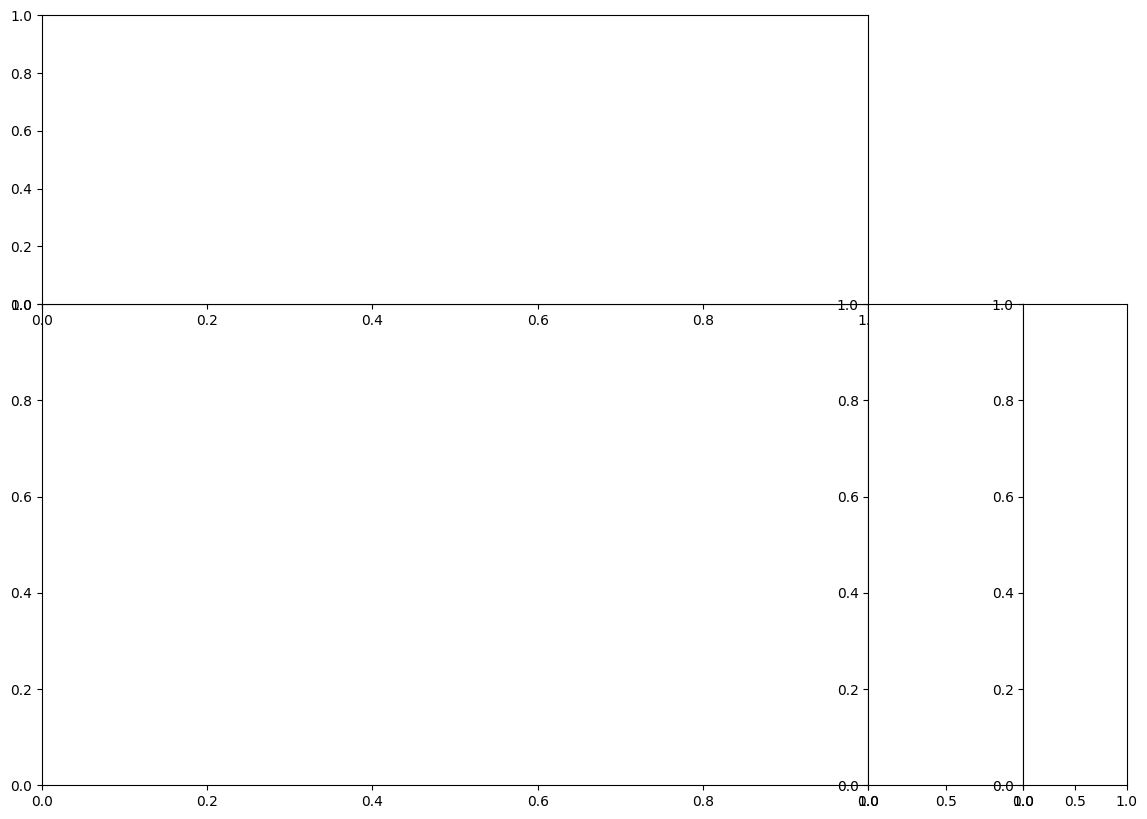

In [15]:
assignment_analysis.market_vis(traff_1[traff_1['Period'].isin([1990])], name_fig = 'market_bts_1990_act_w',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation =  'Av_ac_seats', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [4e3, 6e6], n_market = 22, period_duration = 1, weight = True, format_fig='pdf')

In [139]:
assignment_analysis.assign_vis(traff_1[traff_1['Period'].isin([1990,1991])], [715], title_fig = '715', name_fig = 'test_assign',reso = 400, smooth_param = 0.03, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], 
                                  capac_limits = [2e3, 6e6], vmax = 0.5, period_duration = 1)

Color choice...
Coloriage trouvé : {'B744': 0, 'B752': 1, 'B763': 2, 'DC10': 3, 'A320': 4, 'MD87': 5, 'B772': 6, 'B733': 7, 'A306': 8, 'A319': 9, 'B738': 10, 'A332': 11, 'B737': 12, 'B762': 13, 'B742': 14, 'B734': 15, 'A321': 14, 'B722': 16, 'DC93': 17, 'B77W': 15, 'B735': 18, 'B739': 13, 'B732': 19, 'A388': 8, 'B748': 16, 'A342': 20, 'CRJ2': 19, 'E145': 21, 'B741': 10, 'L101': 11, 'F100': 12, 'E75L': 7, 'B789': 17, 'DC95': 9, 'B712': 16, 'CRJ9': 18, 'B788': 19, 'CRJ7': 17, 'A20N': 5, 'A359': 20, 'A30B': 6, 'A310': 20, 'A21N': 21, 'B721': 12, 'A333': 20, 'B38M': 3, 'B74S': 4, 'B39M': 18, 'DC87': 8, 'A343': 6}


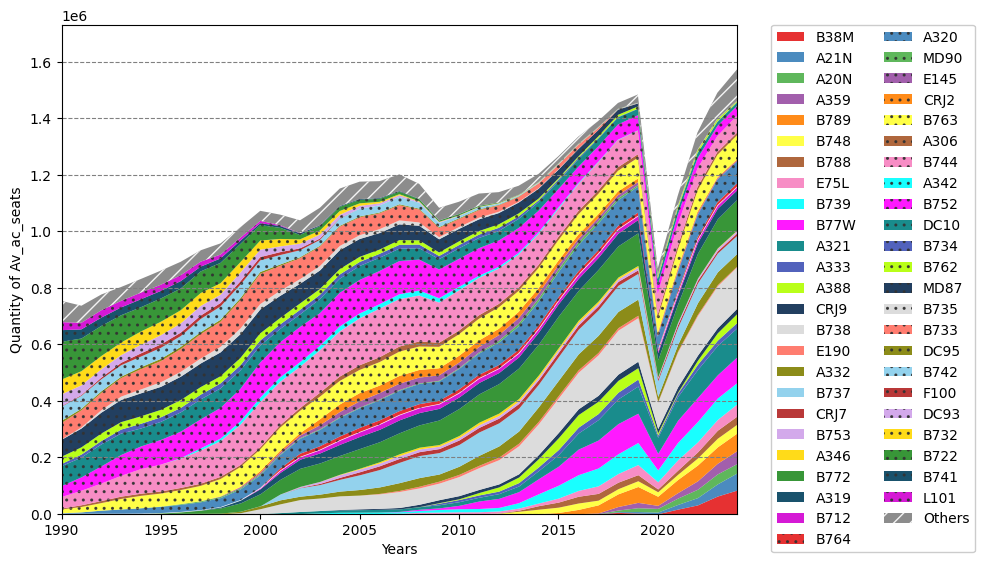

0.0%
8.6%
17.1%
25.7%
34.3%
42.9%
51.4%
60.0%
68.6%
77.1%
85.7%
94.3%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [5]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2025)], video_name = 'history_av_ac_seats',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation = 'Av_ac_seats', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 20, format_v='video', weight = False)

Color choice...
Coloriage trouvé : {'622': 0, '626': 1, '694': 2, '819': 3, '655': 4, '619': 5, '627': 6, '698': 7, '614': 8, '612': 9, '617': 10, '625': 11, '696': 12, '817': 13, '616': 14, '631': 11, '699': 10, '715': 12, '620': 15, '640': 16, '637': 13, '732': 17, '882': 14, '873': 18, '740': 19, '624': 17, '638': 15, '730': 8, '760': 9, '634': 16, '816': 7, '629': 19, '675': 20, '888': 17, '687': 18, '673': 19, '887': 20, '608': 15, '623': 21, '889': 5, '603': 20, '733': 6, '722': 4, '359': 16, '690': 14, '691': 18, '721': 3, '710': 19, '838': 11, '839': 15, '693': 2, '860': 18, '697': 6}


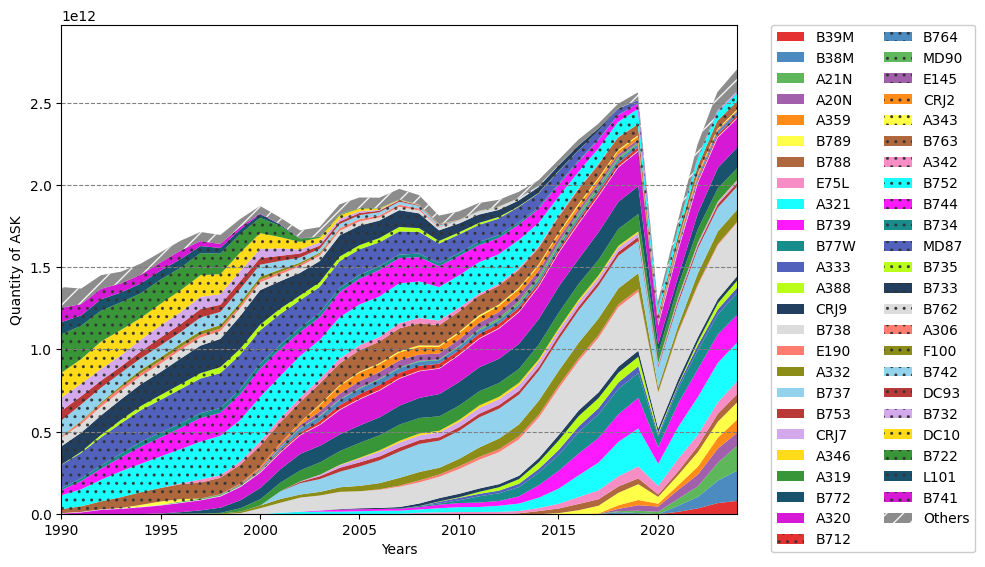

0.0%
8.6%
17.1%
25.7%
34.3%
42.9%
51.4%
60.0%
68.6%
77.1%
85.7%


KeyboardInterrupt: 

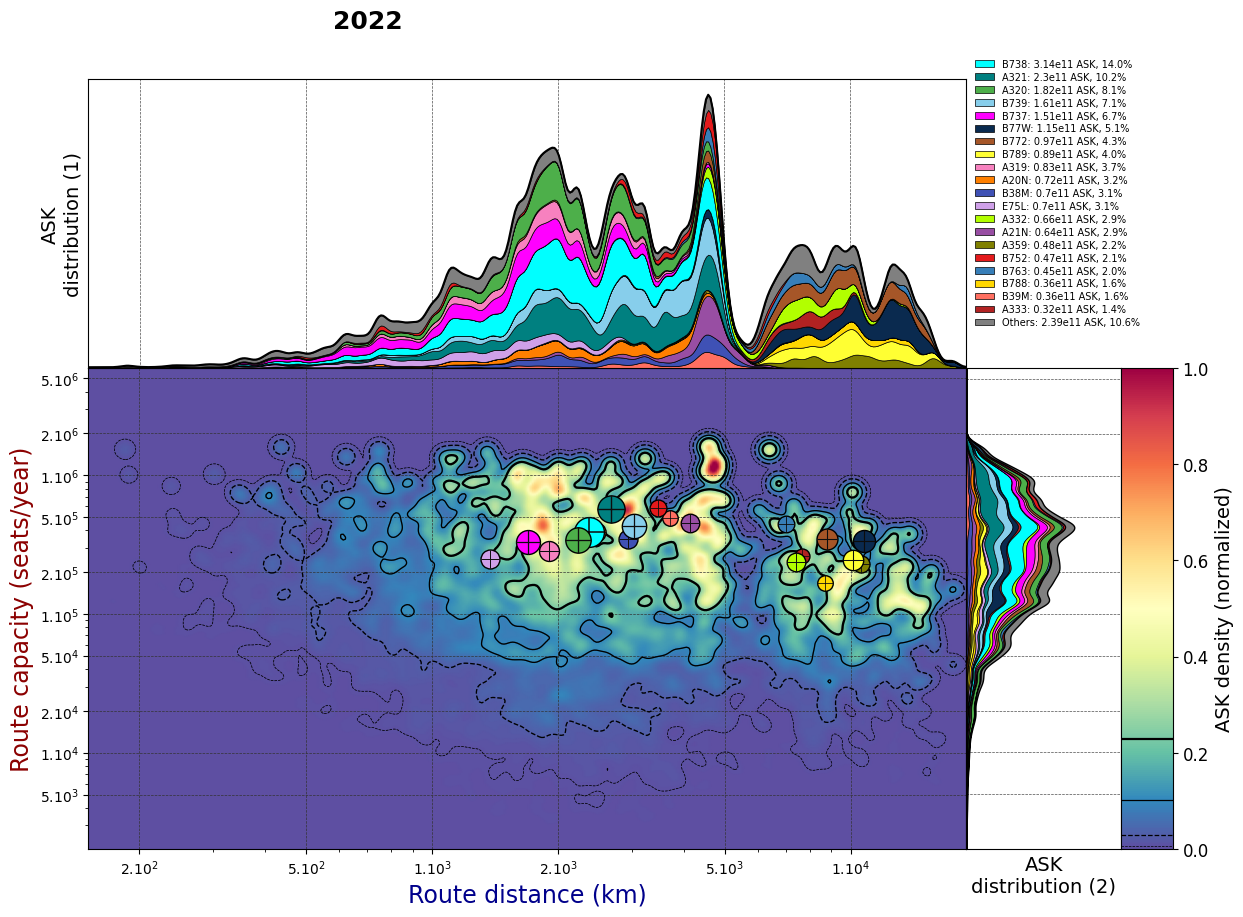

In [56]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2025)], video_name = 'history_US_market_tot_ask',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 20, format_v='video', weight = True)

In [ ]:
traff_c = traff_1[traff_1['Aircraft Operator Name']=='Delta Air Lines Inc.']
assignment_analysis.dynamic_market_vis(traff_c, [i for i in range(1990,2025)], video_name = 'Delta_history_US_market',reso = 400, smooth_param = 0.05, 
                                  market = 'Aircraft Type', observation = 'Av_ac_seats', dist_limits = [1.5e2, 1.9e4], period_ref = 2024,
                                  capac_limits = [2e3, 6e6], n_market = 18, format_v='video')

Color choice...
Coloriage trouvé : {'B738': 0, 'A321': 1, 'B772': 2, 'B763': 3, 'B739': 4, 'B77W': 5, 'A320': 6, 'B744': 7, 'B38M': 8, 'B737': 9, 'B789': 10, 'A21N': 11, 'A332': 12, 'A359': 13, 'B39M': 14, 'A20N': 15, 'B752': 16, 'B748': 17, 'A319': 18, 'E75L': 19, 'B788': 20, 'A388': 21}


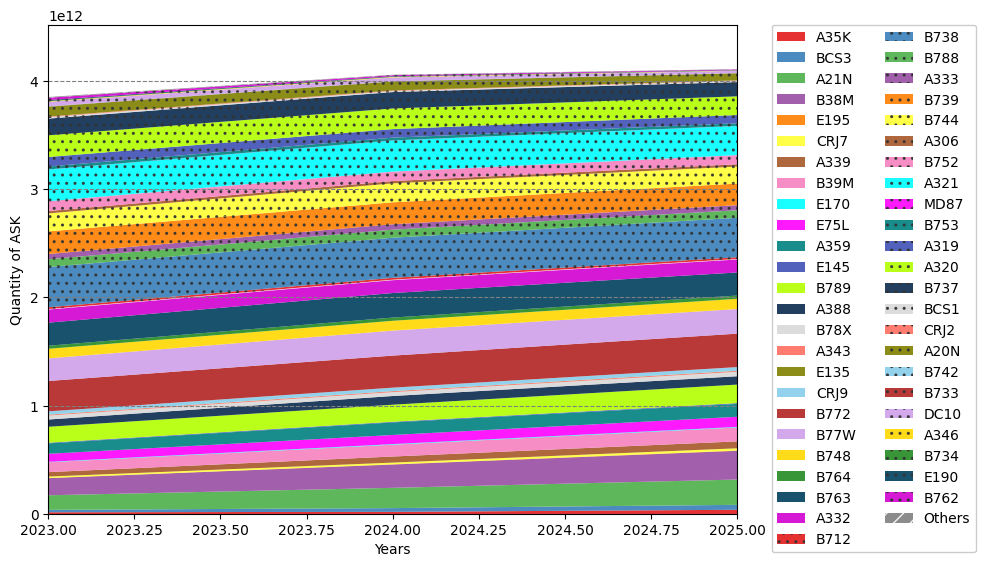

0.0%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [10]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(2023,2026)], video_name = 'US_2023_2025',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [2.9e2, 2.1e4], period_ref = 2025,
                                  capac_limits = [4e3, 6e6], n_market = 22, format_v='video', weight = True)

In [17]:
assignment_analysis.market_vis(traff_1[traff_1['Period']==2025], name_fig = 'market_bts_ask_w_2025_cat',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation =  'ASK', dist_limits = [2.99e2, 2.05e4], 
                                  capac_limits = [5e3, 3.1e6], n_market = 33, period_duration = 1, weight = True, format_fig='png',
                               label_size_param = 1)

chelou rank none


Color choice...
Coloriage trouvé : {'622': 0, '626': 1, '694': 2, '819': 3, '627': 4, '655': 5, '698': 6, '696': 7, '619': 8, '614': 9, '629': 10, '612': 11, '624': 12, '625': 13, '617': 14, '699': 15, '817': 16, '675': 17, '623': 18, '691': 19, '873': 20, '631': 21, '616': 22, '608': 23, '640': 24, '732': 25, '620': 26, '638': 19, '687': 22, '715': 18, '637': 16, '882': 24, '740': 21, '733': 15, '874': 25, '887': 13, '673': 14, '888': 20, '889': 26, '730': 11, '760': 12, '603': 23, '634': 27, '359': 8, '816': 9, '693': 10, '650': 17, '722': 27, '678': 28, '765': 6, '818': 7, '630': 27, '837': 5, '721': 25, '690': 4, '710': 20, '822': 28, '656': 29, '838': 3, '839': 17, '339': 23, '697': 20, '871': 24, '836': 10, '860': 2, '621': 21, '872': 26, '821': 17, '724': 18}


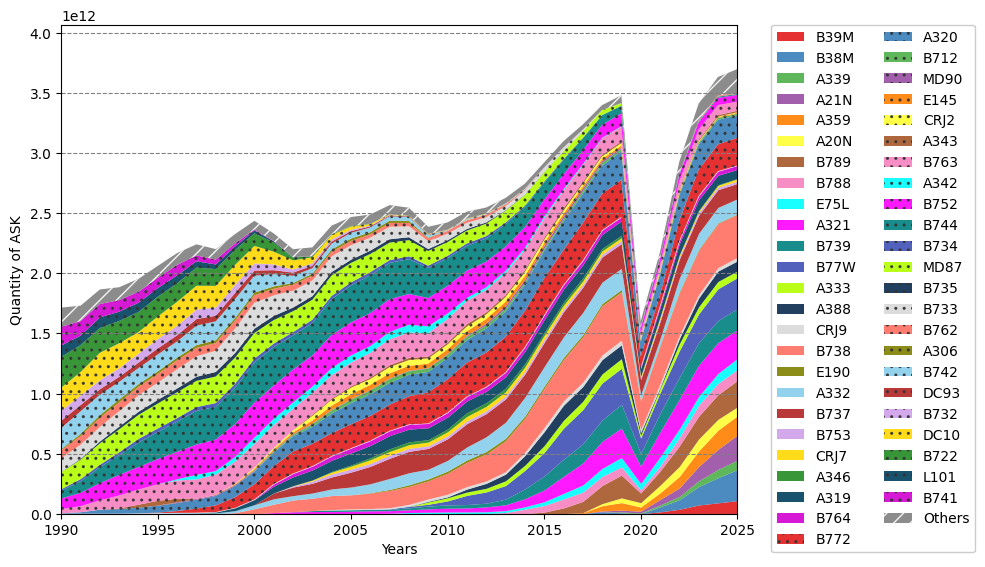

0.0%
8.3%
16.7%
25.0%
33.3%
41.7%
50.0%
58.3%
66.7%
75.0%
83.3%
91.7%


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [5]:
assignment_analysis.dynamic_market_vis(traff_1, [i for i in range(1990,2026)], video_name = 'history_US_market',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation = 'ASK', dist_limits = [2.9e2, 2.05e4], period_ref = 2025,
                                  capac_limits = [2e3, 6e6], n_market = 27, format_v='video', label_size_param = 1.7)

In [18]:
assignment_analysis.assign_vis(df_visu[df_visu['Period'].isin([29])], ['B738'], title_fig = None, name_fig = 'taux_penetration_B738_mod_2019',reso = 200, smooth_param = 0.04, 
                                  market = 'Aircraft Type Name', observation = 'ASK', dist_limits = [2.8e2, 2.1e4], color='#FF00FF',
                                  capac_limits = [9e3, 3e6], vmax = 0.4, period_duration = 1)

In [19]:
assignment_analysis.assign_vis(traff_1[traff_1['Period'].isin([2019])], ['B738'], title_fig = None, name_fig = 'taux_penetration_B738_2019',reso = 200, smooth_param = 0.04, 
                                  market = 'Aircraft Type Name', observation = 'ASK', dist_limits = [2.8e2, 2.1e4], color='#FF00FF',
                                  capac_limits = [9e3, 3e6], vmax = 0.6, period_duration = 1)

In [90]:
assignment_analysis.market_vis(df_visu, name_fig = 'market_bts_2019_ASK_mod',reso = 400, smooth_param = 0.04, 
                                  market = 'Aircraft Type', observation =  'ASK', dist_limits = [2.8e2, 2.1e4], 
                                  capac_limits = [9e3, 3e6], n_market = 16, period_duration = 1, weight = False, format_fig='pdf', label_size_param = 1.1)

NameError: name 'df_visu' is not defined

## Model training & evaluation

In [63]:
### data preparation
obs_choice = 'Av_ac_seats' #'ASK' ou 'Av_ac_seats'
ds_name='bts'#BTS : 'bts', EUROCONTROL : 'ec'
n_choice = 50
d_norm, cap_norm = 15000, 15

if ds_name == 'bts' :
    traff_s = traff_1[traff_1['Period'].isin([2015,2016,2017,2018,2019,2024])]
    traff_cond = traff_s[['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', obs_choice, obs_choice+'_conn_p','N_flights', 'Seats']].groupby(
        ['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', obs_choice+'_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.0025, weight = True,
                                                                                                   obs = obs_choice, save_techn_carac = True, airports = False) #True seulement pour bts
if ds_name == 'ec' :
    traff_s = traff_2[(traff_2['Period']<=19)]
    traff_cond = traff_s[['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p', 'ASK', 'Seats']].groupby(
        ['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', 'ASK_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.01, weight = False,
                                                                                                   obs = obs_choice, save_techn_carac = False, airports = False) #True seulement pour bts

n_y = existence_cache.shape[1]
data_training = np.array(df_training[['Period','Distance_conn (km)','Seats_conn_p','Id_mod',obs_choice+'_w']]) 
obs_norm1 = data_training[:,4].sum()/data_training[:,4].shape[0] #pour une moyenne à 1
obs_norm2 = data_training[:,4].shape[0] #pour une somme à 1
data_training[:,1] = data_training[:,1]/d_norm
data_training[:,2] = np.log(data_training[:,2])/cap_norm
data_training[:,4] = data_training[:,4]/obs_norm1

99.2% Av_ac_seatss selected.


In [65]:
#training

#optimiseur adam, best
# alphas, betas, omegas, likely = assignment_multilogit.fit_function_adam(data_training, existence_cache, ranges, num_epochs = 50, learning_rate = 0.01, n_y = n_y, n_ac = n_choice, 
#                                             title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(0),
#                                             names_ac =list(c_table['Aircraft Type Name']),obs_norm2=obs_norm2, n_batches = 3000, y_min = 2015)
# alphas, betas, omegas, likely = assignment_multilogit.fit_function_adam(data_training, existence_cache, ranges, num_epochs = 200, learning_rate = 0.04, n_y = n_y, n_ac = n_choice, 
#                                             title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(1),
#                                              names_ac =list(c_table['Aircraft Type Name']),obs_norm2=obs_norm2, n_batches = 20,
#                                                 alphas = alphas, betas = betas, omegas = omegas, y_min = 2015)
alphas, betas, omegas, likely = assignment_multilogit.fit_function_adam(data_training, existence_cache, ranges, num_epochs = 1000, learning_rate = 0.1, n_y = n_y, n_ac = n_choice, 
                                                                 title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(2),
                                                                   names_ac =list(c_table['Aircraft Type Name']),obs_norm2=obs_norm2, n_batches = 1,
                                                                  alphas = alphas, betas = betas, omegas = omegas, y_min = 2015)

# Optimiseur BFGS, semble moins bien marcher...
# alphas, betas, omegas = assignment_multilogit.load_estim(name ='logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(4)+'_BFGS')
# alphas, betas, omegas, likely = assignment_multilogit.fit_function_bfgs(data_training, existence_cache, ranges, num_epochs = 1000, n_y = n_y, n_ac = n_choice, 
#                                                                  title = 'logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(4),
#                                                                    names_ac =list(c_table['Aircraft Type Name']),obs_norm2=obs_norm2,
#                                                                        alphas = alphas, betas = betas, omegas = omegas)



Without training -2.52997
epoch 0; Log-likelihood = -2.54731
epoch 1; epoch 2; epoch 3; epoch 4; epoch 5; Log-likelihood = -2.53139
epoch 6; epoch 7; epoch 8; epoch 9; epoch 10; Log-likelihood = -2.53004
epoch 11; epoch 12; epoch 13; epoch 14; epoch 15; Log-likelihood = -2.52958
epoch 16; epoch 17; epoch 18; epoch 19; epoch 20; Log-likelihood = -2.52853
epoch 21; epoch 22; epoch 23; epoch 24; epoch 25; Log-likelihood = -2.52766
epoch 26; epoch 27; epoch 28; epoch 29; epoch 30; Log-likelihood = -2.52705
epoch 31; epoch 32; epoch 33; epoch 34; epoch 35; Log-likelihood = -2.52665
epoch 36; epoch 37; epoch 38; epoch 39; epoch 40; Log-likelihood = -2.52639
epoch 41; epoch 42; epoch 43; epoch 44; epoch 45; Log-likelihood = -2.52616
epoch 46; epoch 47; epoch 48; epoch 49; epoch 50; Log-likelihood = -2.52594
epoch 51; epoch 52; epoch 53; epoch 54; epoch 55; Log-likelihood = -2.52575
epoch 56; epoch 57; epoch 58; epoch 59; epoch 60; Log-likelihood = -2.52558
epoch 61; epoch 62; epoch 63; epoch 

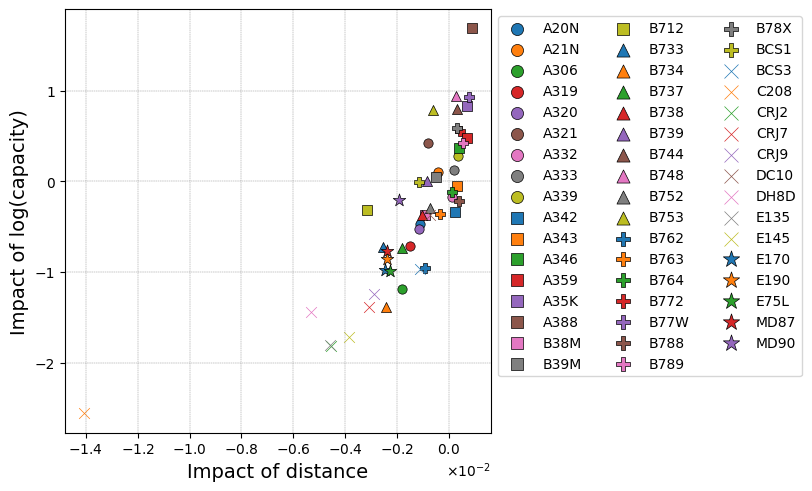

avg relative error : 0.03581042121926265
obs_weighted avg relative error : 0.03005384260374676


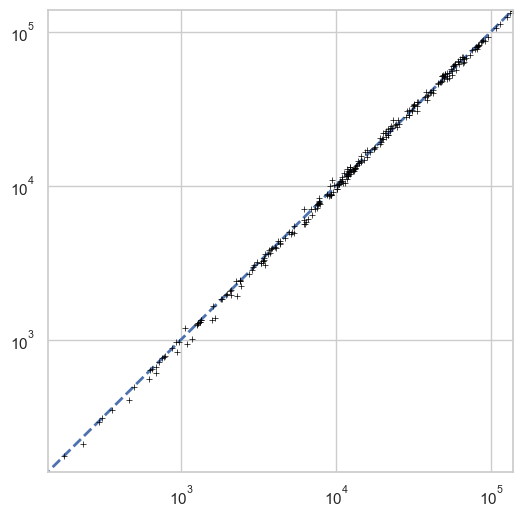

0.06985675298343438 0.1429964803067172


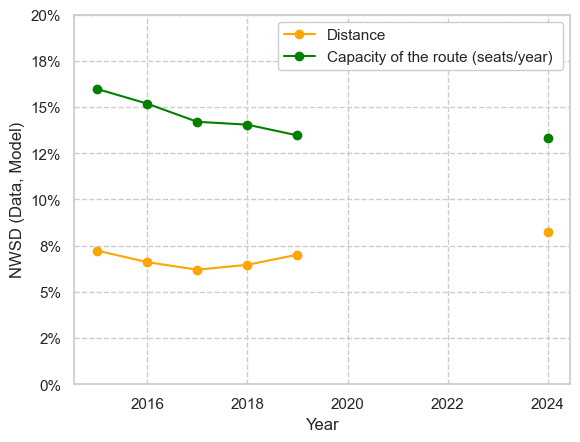

In [66]:
alphas_t, betas_t, omegas_t, names_ac =  assignment_multilogit.load_estim(name ='logit_model_'+ds_name+'_'+obs_choice+'_'+str(n_choice)+'_'+str(n_y)+'_'+str(2)+'_19', columns = True)
assignment_multilogit.visu_coeffs(alphas, betas, names_ac,ds_name, d_norm = d_norm, cap_norm= cap_norm)
connec_training = np.array(connections[['Period', 'Distance_conn (km)','Seats_conn_p',obs_choice+'_w_mod']])
shares_pred = assignment_multilogit.predict_assignt(connec_training, existence_cache,alphas_t,betas_t,omegas_t,ranges, d_norm=d_norm, cap_norm=cap_norm)
assignment_multilogit.obs_comp(data_training, connec_training, shares_pred, obs_norm1,obs_norm2)
assignment_multilogit.nwsd(existence_cache, data_training, connec_training, shares_pred, d_norm, cap_norm, obs_norm1, year_ref = 2015, freq = 1)

MSE : 13.722e-8
R^2 : 0.976


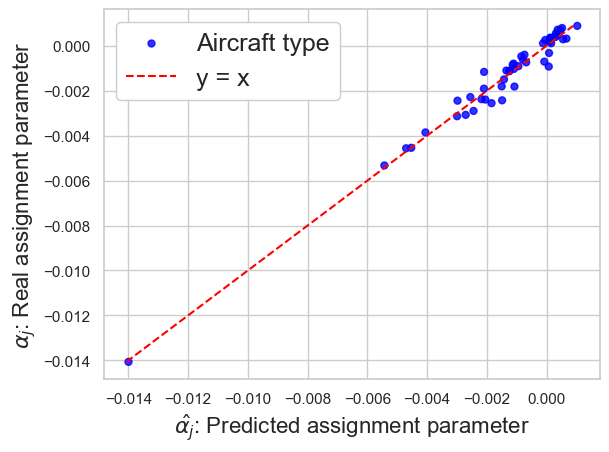

MSE : 1.347e-1
R^2 : 0.809


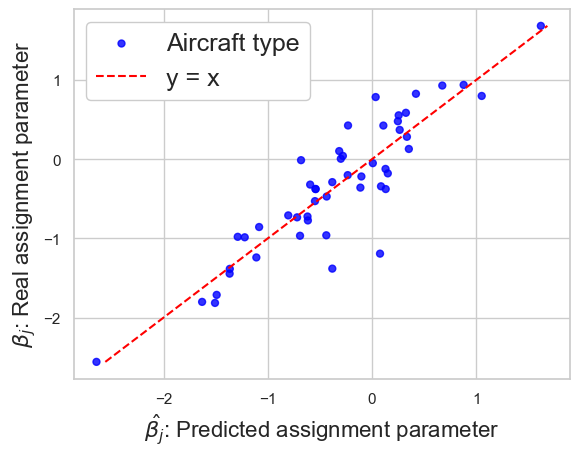

MSE : 7.050e-8
R^2 : 0.952


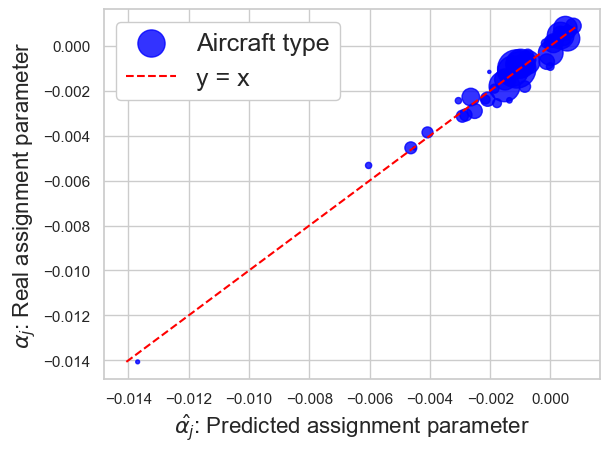

MSE : 0.834e-1
R^2 : 0.820


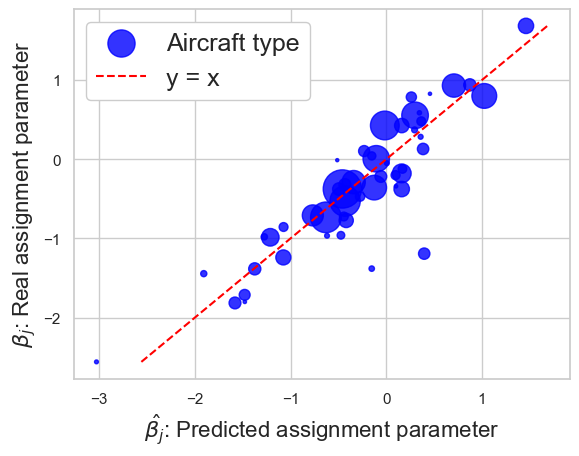

MSE : 6.745e-8
R^2 : 0.942


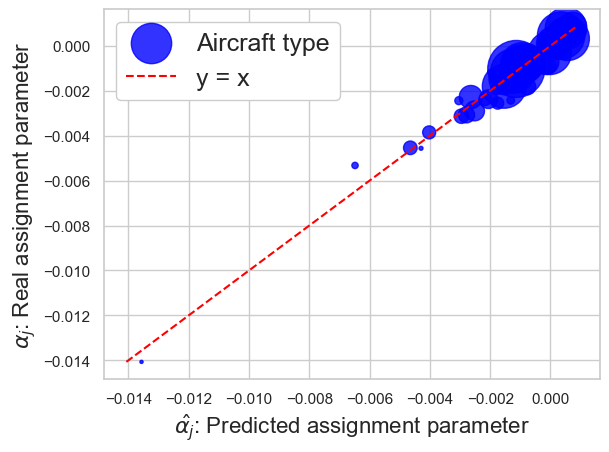

MSE : 0.834e-1
R^2 : 0.820


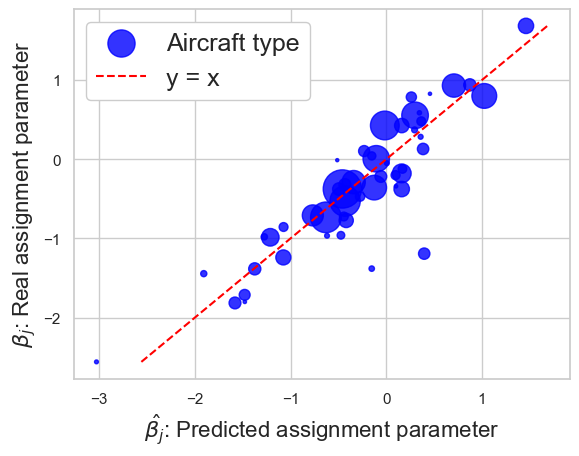

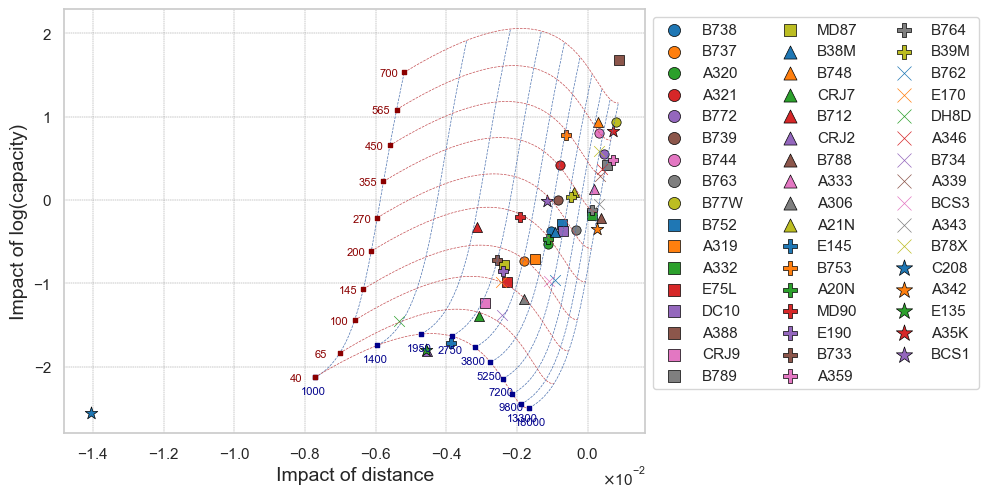

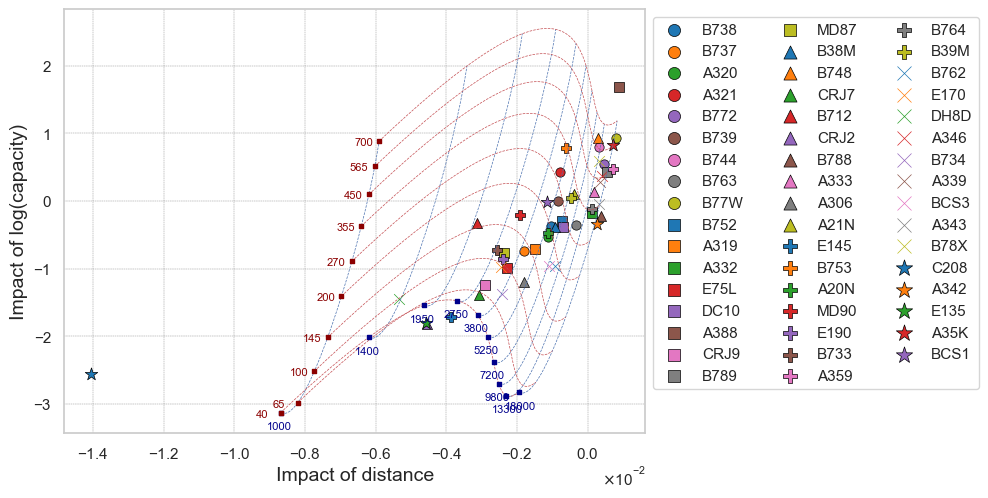

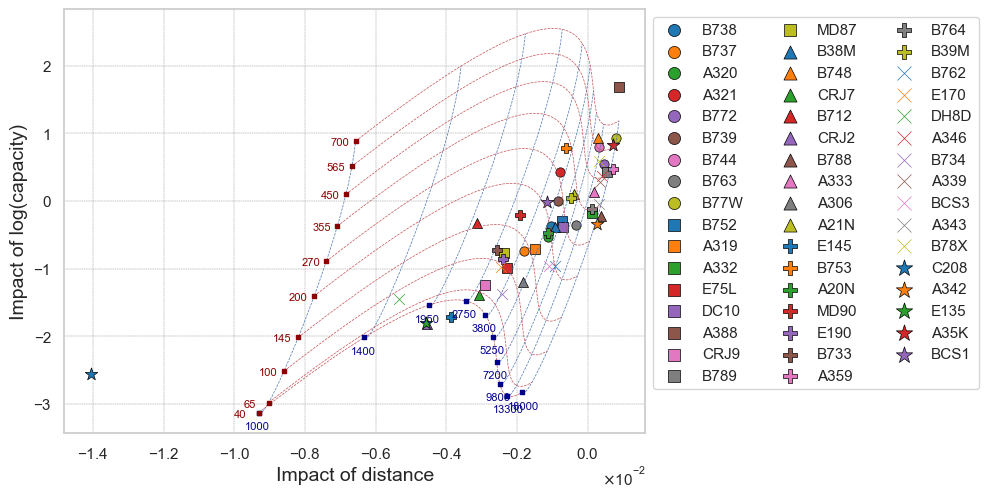

In [67]:
#strictement réservé à BTS, associé à une bdd technique.
correspondance_table = assignment_multilogit.correspondance_table(title_coeffs = 'logit_model_bts_Av_ac_seats_50_10_2_19',title_tech = 'BTS_Av_ac_seats_50_10', 
                                                                  obs_choice = 'Av_ac_seats', d_norm = d_norm, cap_norm= cap_norm)
coeffs_alphas, coeffs_betas =assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = False, obs_choice = obs_choice)
coeffs_alphas_w, coeffs_betas_w = assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = True, obs_choice = obs_choice)
coeffs_alphas_wl, coeffs_betas_wl = assignment_multilogit.regressor_assign_coeffs(correspondance_table, weight = True,weight_log = True, obs_choice = obs_choice)

assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas, coeffs_betas, reg_name='bts_ASK_58_30')
assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas_w, coeffs_betas_w, reg_name='bts_ASK_58_30_w')
assignment_multilogit.regressor_visu_model(correspondance_table,coeffs_alphas_wl, coeffs_betas_wl, reg_name='bts_ASK_58_30_wl')

alpha_mod, beta_mod, seats_mod, ranges_mod = assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, 180, 9000)

# Scenarios

## Advanced US 2024 scenario

On choisit désormais un scénario à modéliser. 3 options s'offrent à nous : 
1) Echelle Monde. On dispose de la flotte, mais pas du traffic exact.
2) Echelle US. On dispose du trafic, des coefficients d'allocation et des caractéristiques techniques. Idéal.
3) Echelle Europe. On dispose du trafic, des coefficients d'allocation, et les caractéristiques techniques pourraient être calculées, mais pas fait.

On garde donc US. Il nous manque cependant des bonnes données sur la dégradation de l'activité avec l'âge. Pour l'instant, on suppose -1% par an (cf travaux pas publié - par ailleurs associés à des biais méthodo), tout paramètre étalonné dans d'autres travaux, serait également raisonnable (kuhlen : - 0.6%).
On sélectionne 50 modèles d'avions (99.2% des sièges d'avions), uniquement sur l'année 2024, et la pyramide des âges de cette flotte au pro rate du mondial. On considère la flotte des avions produits jusqu'en 2024 et retirés jusqu'en 2024. On pourrait ajouter un facteur 0.5 pour tenir compte des effets de marge, mais on le néglige pour l'instant.

Les orientations suivantes sont choisies :
1) Utiliser des ASKs équivalents. Cela suppose d'adapter le traitement de la base de données pour mettre des sièges éco max.
2) Ne pas intégrer - pour l'instant - le taux de remplissage comme ça pose bcp de questions méthodo.
3) Pour valider la méthode intégrée, il pourrait être intéressant de répliquer la méthodo en partant de 2010 jusqu'à 2019.

In [41]:
taux_utilisation_usuel = 0.85
aging_activity_coeff = 0.0#0.01 normalement
croiss_an  = 0.01
period_duration = 1 #2**-i

### Types selection and traffic identification

In [42]:
modeled_aircraft = assignment_multilogit.correspondance_table(title_coeffs = 'logit_model_bts_Av_ac_seats_50_10_2_19',title_tech = 'BTS_Av_ac_seats_50_10', 
                                                              obs_choice = 'Av_ac_seats')
modeled_aircraft.drop(columns='Av_ac_seats_weight', inplace = True)
modeled_aircraft.reset_index(inplace=True, drop = True)
seats_map = modeled_aircraft['Est_avg_seats'].to_dict()
ids_map = modeled_aircraft['Aircraft Type Name'].to_dict()
type_ids_map = {valeur: cle for cle, valeur in ids_map.items()}

types_obs_list = list(modeled_aircraft['Aircraft Type Name'])

traff_agg_2024 = traff_1[(traff_1['Period']== 2024)&(traff_1['Aircraft Type Name'].isin(types_obs_list))]
traff_2024_f, waste2, waste4, waste3, connections = assignment_multilogit.data_formatting(traff_agg_2024, n_ac= len(types_obs_list), seuils_f = 0.0025, weight = True, 
                                                                                    obs = 'Av_ac_seats', save_techn_carac = False, airports = True)

traff_2024_f['Activity_w'] = traff_2024_f['Av_ac_seats_w']/traff_2024_f['Id_mod'].map(seats_map)/taux_utilisation_usuel
traff_2024_f['Aircraft Type Name'] = traff_2024_f['Id_mod'].map(ids_map)

L_types = traff_2024_f[['Aircraft Type Name', 'Activity_w','Av_ac_seats_w']].groupby('Aircraft Type Name').sum().reset_index()
L_types = L_types[L_types['Aircraft Type Name'].isin(types_obs_list)].sort_values(by = 'Activity_w', ascending = False)
ids_bts = sorted(list(L_types['Aircraft Type Name']))

modeled_aircraft = modeled_aircraft.merge(L_types, left_on = 'Aircraft Type Name', right_on = 'Aircraft Type Name', how='left')
modeled_aircraft = modeled_aircraft.fillna(0)

100.0% Av_ac_seatss selected.


### Fleet age structure

In [43]:
taa_ICAO_names = pd.read_csv('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/aircraft_codes_taa_icao.csv', sep =';')
dico_taa_icao = dict(zip(list(taa_ICAO_names['Aircraft Type']), list(taa_ICAO_names['ICAO_Code'])))
df_ac_taa = pd.read_excel('D:\p.viry\Documents\Travail_recherche\Data\TAA\TAA_fleet/fleet_extract_250610.xlsx')[['MSN','Type','Model','Exp. Delivery','Year Built','Status','Date']]
df_ac_taa['Year Built']= df_ac_taa['Year Built'].fillna(df_ac_taa['Exp. Delivery'])
df_ac_taa = df_ac_taa[df_ac_taa['Year Built']!='12/30/1899']
df_ac_taa = df_ac_taa[~df_ac_taa['Year Built'].isna()]
df_ac_taa['Year Built'] = df_ac_taa['Year Built'].apply(vis_ref.date_to_float_year)
df_ac_taa['Date'] = df_ac_taa['Date'].apply(vis_ref.date_to_float_year)

df_ac_taa_a = df_ac_taa[(df_ac_taa['Status'].isin(['Active']))|(df_ac_taa['Date']>=2025)]
df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Type'].astype(str) + df_ac_taa_a['Model'].astype(str)
df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Aircraft Type'].map(dico_taa_icao)
df_ac_taa_a = df_ac_taa_a[~df_ac_taa_a['Aircraft Type'].isna()]

df_ac_taa_a.drop(columns =['Type', 'Model','MSN','Exp. Delivery','Status','Date'], inplace = True)
df_ac_taa_a = df_ac_taa_a[df_ac_taa_a['Year Built']<2025]
df_ac_taa_a.reset_index(drop = True, inplace = True)

In [44]:
df_ac_taa_a = df_ac_taa_a[df_ac_taa_a['Aircraft Type'].isin(ids_bts)]
dico2 = dict(zip(modeled_aircraft['Aircraft Type Name'],modeled_aircraft.index))
df_ac_taa_a['Aircraft Type'] = df_ac_taa_a['Aircraft Type'].map(dico2)
y_min = df_ac_taa_a['Year Built'].min()
df_ac_taa_a['Year Built'] =  (df_ac_taa_a['Year Built'] - y_min).astype(int)
n_y_f = df_ac_taa_a['Year Built'].max()+1

In [45]:
n = int(modeled_aircraft.index.max() + 1)

counts = (
    df_ac_taa_a
    .groupby(['Aircraft Type', 'Year Built'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(n), columns=range(n_y_f), fill_value=0)
)

proportions = counts.div(counts.sum(axis=1), axis=0).to_numpy()
proportions[np.isnan(proportions)] = 0
#integration of productivity effects : older fleet will seem smaller
weighted_prop = np.exp(aging_activity_coeff*(-n_y_f+1+np.arange(n_y_f)))
activity_per_aircraft = (weighted_prop[None,:]*proportions).sum(axis = 1)
activity_per_aircraft[activity_per_aircraft==0] = 1
initial_fleet_r = (proportions*modeled_aircraft['Activity_w'].values[:, None]/activity_per_aircraft[:, None]).T

### Scenario definition

In [46]:
#la première condition prévient les bugs, la deuxième et la troisième accélèrent le code à moindre coût. Cela coûte 0.2% du traffic en combiné.
connections_valid = connections[(connections['Distance_conn (km)']<modeled_aircraft['Est_max_range'].max())&(connections['Seats_conn_p']>1000)&(connections['Distance_conn (km)']>100)]

#ici, voici la version qui aggrège
d_min, d_max = connections_valid['Distance_conn (km)'].min(), connections_valid['Distance_conn (km)'].max()
c_min, c_max = connections_valid['Seats_conn_p'].min(), connections_valid['Seats_conn_p'].max()
N=50
d_bins = np.logspace(np.log10(d_min), np.log10(d_max), N + 1)
c_bins = np.logspace(np.log10(c_min), np.log10(c_max), N + 1)
grouped = (
    connections_valid
    .groupby([
        pd.cut(connections_valid['Distance_conn (km)'], d_bins, include_lowest=True),
        pd.cut(connections_valid['Seats_conn_p'], c_bins, include_lowest=True)
    ])['Av_ac_seats_w_mod']
    .sum()
    .unstack(fill_value=0)
)
df_long = grouped.stack().reset_index()
df_long.columns = ['d_bin', 'c_bin', 'Av_ac_seats_w_mod']

df_long['Distance_conn (km)'] = df_long['d_bin'].apply(lambda x: np.sqrt(x.left * x.right))
df_long['Seats_conn_p'] = df_long['c_bin'].apply(lambda x: np.sqrt(x.left * x.right))
connections_light = df_long[['Distance_conn (km)', 'Seats_conn_p', 'Av_ac_seats_w_mod']]
connections_light['ADES'] = connections_light.index
connections_light['ADEP'] = connections_light.index + connections_light.shape[0]
connections_light['Period'] = 0

traffic_structures_ini = np.array(connections_valid[['ADES','ADEP','Period', 'Distance_conn (km)','Seats_conn_p','Av_ac_seats_w_mod']])
# traffic_structures_ini = np.array(connections_light[['ADES','ADEP','Period', 'Distance_conn (km)','Seats_conn_p','Av_ac_seats_w_mod']])
traff_struct_l = [traffic_structures_ini]
modeled_periods = int(31/period_duration+1) #until 2055

traffic_structures_add = traffic_structures_ini.copy()
for i in range(modeled_periods-1):
    # rd_array = np.random.random(traffic_structures_ini.shape[0])

    # traffic_structures_add[:,4] =  (0.985+0.03*rd_array)*(traffic_structures_add[:,4]) #variabilité fake

    # traffic_structures_add[:,2] +=1
    # traffic_structures_add[:,5] = (0.985+0.03*rd_array)*traffic_structures_add[:,5]*(1+(0.5+1.1*(traffic_structures_add[:,3]>5000))*croiss_an)**(period_duration) #evol traffic

    traff_struct_l.append(traffic_structures_add.copy())
traffic_structures = np.array(traff_struct_l)

In [110]:
#existing aircraft
types_names = list(modeled_aircraft['Aircraft Type Name'])
ranges = np.array(modeled_aircraft['Est_max_range'])
obs_sizes = np.array(modeled_aircraft['Est_avg_seats'])
alphas = np.array(modeled_aircraft['alphas'])
betas = np.array(modeled_aircraft['betas'])

#introduced aircraft specification
# dict_new_ac = {
#     'Aircraft Type Name':['RJ1', 'NB LR1', 'WB LR1', 'WB SR1','RJ2', 'NB LR2', 'WB SR2', 'WB LR2'],
#                'Seats' : [140, 220, 400, 600, 140, 220, 600, 400],
#             'Ranges' : [5000, 9000, 19000, 4000, 6000, 12000, 5000, 20000],
#             'EIS' : [2024, 2024, 2024, 2030, 2040, 2040, 2050, 2050],
#             'Production_duration': [20,20,20,20,20,20,20,20],
#             'Production_delay' :  [8,8,8,8,8,8,8,8],
#             'Replaced_traffic_share' :  [0.3,0.3,0.3,0.3,0.3,0.3,0.3,0.3]
#               }
dict_new_ac = {
    'Aircraft Type Name':['Test_aircraft'],
               'Seats' : [50],
            'Ranges' : [4000],
            'EIS' : [2024],
            'Production_duration': [50],
            'Production_delay' :  [15],
            'Replaced_traffic_share' :  [0.35]
              }
df_new = pd.DataFrame(dict_new_ac)
coeffs_alphas_w, coeffs_betas_w = assignment_multilogit.regressor_assign_coeffs(modeled_aircraft, weight = True, obs_choice = 'Av_ac_seats', visu = False)
for ac in range(df_new.shape[0]):
    ac_name = df_new['Aircraft Type Name'][ac]
    ac_range = df_new['Ranges'][ac]
    ac_seats = df_new['Seats'][ac]
    ac_alpha, ac_beta =  assignment_multilogit.assign_coeffs_pred(coeffs_alphas_w, coeffs_betas_w, ac_seats, ac_range)

    types_names.append(ac_name)
    ranges = np.concatenate([ranges, np.array([ac_range])])
    obs_sizes = np.concatenate([obs_sizes, np.array([ac_seats])])
    alphas = np.concatenate([alphas, np.array([ac_alpha])])
    betas = np.concatenate([betas, np.array([ac_beta])])
omegas_0 = np.zeros(betas.shape[0])[:, None]

$\text{Deliveries}(t) = \mu \times (t-t_i) \times (t_f-t) \times e^{\gamma t}$

adapted version : smoothed production


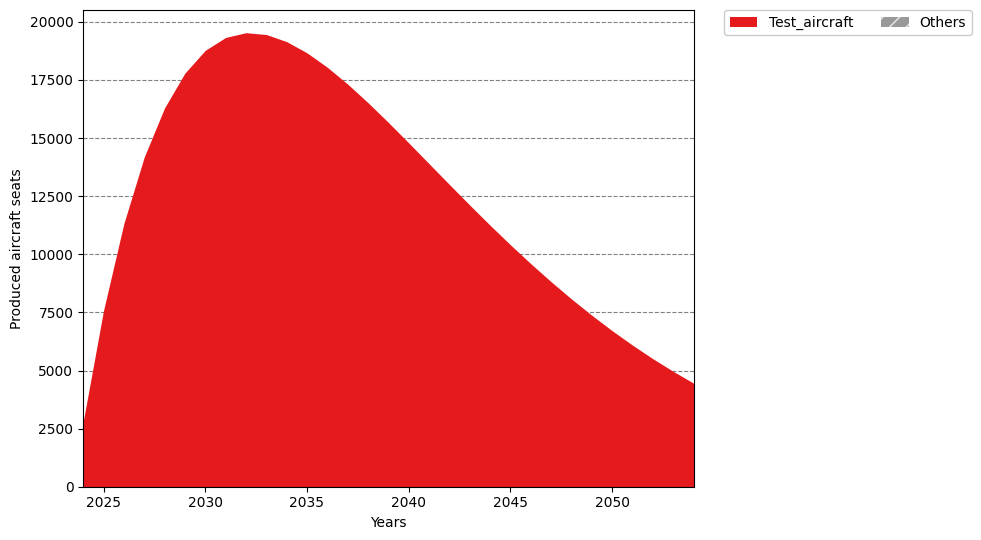

In [111]:
print('adapted version : smoothed production')
initial_fleet = np.hstack((initial_fleet_r, np.zeros((initial_fleet_r.shape[0], df_new.shape[0]))))
initial_fleet = np.vstack((initial_fleet, np.zeros((modeled_periods, initial_fleet.shape[1]))))
deliveries_ini = np.zeros(initial_fleet.shape[1])
deliveries = np.array([deliveries_ini]*modeled_periods)

seats_tot_ini = traffic_structures_ini[:,-1].sum()

# list_new_deliv = ['A21N','A35K'] #to handle the start.
# renewal_share = 0.04
# for ac_type in list_new_deliv:
#     id_list = type_ids_map[ac_type]
#     for t in range(int(5/period_duration)):
#         deliveries[t+1,id_list] = seats_tot_ini*renewal_share/(5*4/2)/obs_sizes[id_list]*(5-t*period_duration)*period_duration #+1->empty_delivery first

for ac in range(df_new.shape[0]):
    eis = int((df_new['EIS'][ac]-2024)/period_duration) 
    duration = df_new['Production_duration'][ac]
    time_to_market = df_new['Production_delay'][ac]
    prod_volume =seats_tot_ini*df_new['Replaced_traffic_share'][ac]
    seats_ac= df_new['Seats'][ac]
    mu, gamma = vis_ref.solve_deliv(time_to_market,duration)
    for t in range(int(duration/period_duration)):
        if eis+t+1<modeled_periods:
            deliveries_ac_t = prod_volume * mu * vis_ref.I_d(gamma,duration,t*period_duration,(t+1)*period_duration) / seats_ac
            deliveries[eis+t+1,-df_new.shape[0]+ac] = deliveries_ac_t #+1->empty_delivery first

fleet_analysis.visu_deliveries_array(deliveries[1:],obs_sizes, types_names,period_duration,min(20, len(types_names)),graph_name = 'Aircraft production')

In [112]:
# print('initial version')
# initial_fleet = np.hstack((initial_fleet_r, np.zeros((initial_fleet_r.shape[0], df_new.shape[0]))))
# initial_fleet = np.vstack((initial_fleet, np.zeros((modeled_periods, initial_fleet.shape[1]))))
# new_deliveries_ini = np.zeros((1, initial_fleet.shape[1]))
# deliveries = np.array([new_deliveries_ini])

# for i in range(int(5/period_duration)):
#     new_deliveries = np.zeros((1, initial_fleet.shape[1]))
#     new_deliveries[:,-8] = (235+2.8*i)*period_duration
#     new_deliveries[:,-7] = (235+2.8*i)*period_duration
#     new_deliveries[:,-5] = (2*i)*period_duration #pour gérer les problèmes sur le lr
#     deliveries = np.concatenate([deliveries,[new_deliveries]])
# for i in range(int(10/period_duration)):
#     new_deliveries = np.zeros((1, initial_fleet.shape[1]))
#     new_deliveries[:,-8] = (125+2.40*i)*period_duration
#     new_deliveries[:,-7] = (125+2.40*i)*period_duration
#     new_deliveries[:,-6] = (28+0.62*i)*period_duration
#     new_deliveries[:,-5] = (28+0.62*i)*period_duration
#     deliveries = np.concatenate([deliveries,[new_deliveries]])
# for i in range(int(10/period_duration)):
#     new_deliveries = np.zeros((1, initial_fleet.shape[1]))
#     new_deliveries[:,-4] = (190+i)*period_duration
#     new_deliveries[:,-3] = (190+i)*period_duration
#     new_deliveries[:,-6] = (30+0.35*i)*period_duration
#     new_deliveries[:,-5] = (30+0.35*i)*period_duration
#     deliveries = np.concatenate([deliveries,[new_deliveries]])
# for i in range(int(5/period_duration)):
#     new_deliveries = np.zeros((1, initial_fleet.shape[1]))
#     new_deliveries[:,-4] = (180+3.5*i)*period_duration
#     new_deliveries[:,-3] =(180+3.5*i)*period_duration
#     new_deliveries[:,-2] = (30+1.1*i)*period_duration
#     new_deliveries[:,-1] =  (30+1.1*i)*period_duration
#     deliveries = np.concatenate([deliveries,[new_deliveries]])

# print('construire des fits qui permettent de lisser ces fonctions ??, écart type, moyenne, kurtosis??')

In [113]:
stats, beta, list_mod = retirement_prio.load_prop_lin(title = 'TAA_propension_lin_icao')
stats = np.where(np.isnan(stats),0, stats)

propensions = -6*np.ones((initial_fleet.shape[0], initial_fleet.shape[1]))
time_array = np.concatenate([np.arange(initial_fleet_r.shape[0]),initial_fleet_r.shape[0]+period_duration*np.arange(modeled_periods)])
propensions+= beta*time_array[:,None]
for i, val in zip(list_mod, stats):
    propensions[:,i] +=val  

In [114]:
FB_seymm = pd.read_csv('D:/p.viry/Documents/Travail_recherche/Data/FB models ext/ac_model_coefficients.csv', sep=';')
print('ajouter le 742 et dc10, avec des avions ressemblant - 744 et 734?, on prend moteur A300B')
line_ref = FB_seymm[FB_seymm['ac_code_icao']=='A30B']
line_742 = line_ref.copy()
line_742['ac_code_icao'] = 'B742'
line_dc10 = line_ref.copy()
line_dc10['ac_code_icao'] = 'DC10'
FB_seymm = pd.concat([FB_seymm,line_742], ignore_index=True)
FB_seymm = pd.concat([FB_seymm,line_dc10], ignore_index=True)
FB_seymm = FB_seymm[FB_seymm['ac_code_icao'].isin(set(list(modeled_aircraft['Aircraft Type Name'])))].drop(columns = ['Unnamed: 0'])
FB_seymm.reset_index(inplace = True)
FB_seymm.drop(columns = ['index'], inplace = True)
FB_seymm['index'] =FB_seymm.index

fb_ini = FB_seymm[['reduced_fuel_a1','reduced_fuel_a2', 'reduced_fuel_intercept']].values
fb_ini = np.concatenate([fb_ini, np.array(4*[[0,3,0]]+2*[[0,2,0]]+[[0,0.2,0]]+[[0,2,0]])])

dico_seymm = dict(zip(FB_seymm['ac_code_icao'], FB_seymm['index']))
dict_add = dict(zip(types_names[-8:], range(len(dico_seymm), len(dico_seymm)+8)))
dico_seymm.update(dict_add)

ajouter le 742 et dc10, avec des avions ressemblant - 744 et 734?, on prend moteur A300B


## Calculations

Computing fleet composition, 32 periods: 0.0% 3.1% 6.3% 9.4% 12.5% 15.6% 18.8% 21.9% 25.0% 28.1% 31.3% 34.4% 37.5% 40.6% 43.8% 46.9% 50.0% 53.1% 56.3% 59.4% 62.5% 65.6% 68.8% 71.9% 75.0% 78.1% 81.3% 84.4% 87.5% 90.6% 93.8% 96.9% 


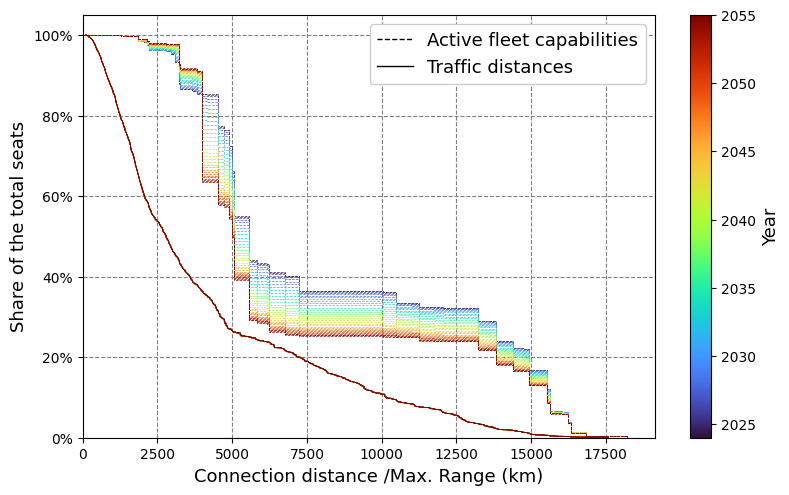

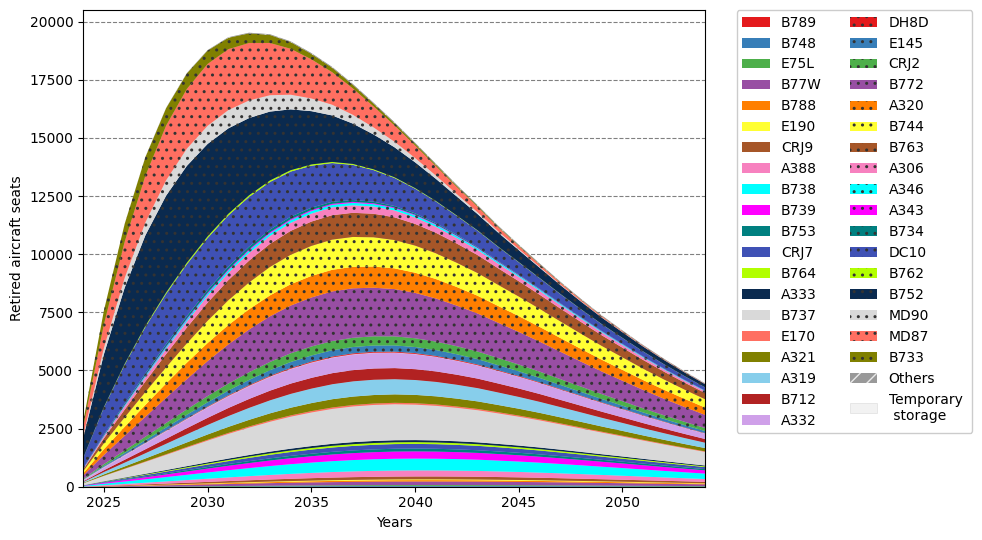

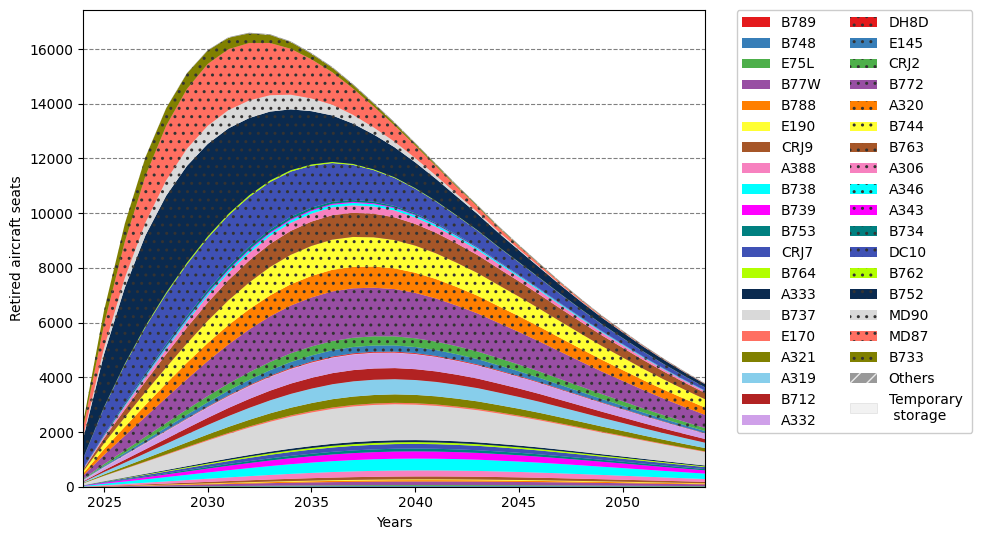

In [115]:
vol_obs, vol_act = global_modelling.compute_fleet_composition(
    initial_fleet, deliveries, obs_sizes, traffic_structures,
    propensions,
    aging_activity_coeff=aging_activity_coeff, period_duration = period_duration,
    taux_utilisation_usuel=taux_utilisation_usuel, precision = 1e-5
)
fleet_analysis.constraint_plot(traffic_structures[:,:,[3,5]],vol_act.sum(axis=1),ranges, years = [2024,2024+modeled_periods*period_duration-1], format = 'png')
fleet_analysis.visu_retirements_array(vol_obs, types_names,period_duration,min(20, len(types_names)),graph_name = 'Aircraft retirements demo')
fleet_analysis.visu_retirements_array(vol_act, types_names,period_duration,min(20, len(types_names)),graph_name = 'Eq. aircraft retirements incl. aging demo')

Computing fleet assignment, 32 periods: 0.0% 3.1% 6.3% 9.4% 12.5% 15.6% 18.8% 21.9% 25.0% 28.1% 31.3% 34.4% 37.5% 40.6% 43.8% 46.9% 50.0% 53.1% 56.3% 59.4% 62.5% 65.6% 68.8% 71.9% 75.0% 78.1% 81.3% 84.4% 87.5% 90.6% 93.8% 96.9% Ok.
Color choice...
Coloriage trouvé : {0: 0, 4: 1, 6: 2, 8: 3, 1: 4, 7: 5, 2: 6, 3: 7, 5: 8, 11: 9, 14: 10, 9: 11, 16: 12, 10: 13, 13: 14, 19: 15, 12: 16, 18: 17, 15: 18, 23: 19, 24: 20, 26: 21, 20: 22, 21: 23, 25: 24, 28: 25, 22: 26, 29: 27, 33: 28, 31: 29, 50: 30, 17: 31, 27: 32, 34: 33, 30: 33, 35: 31}


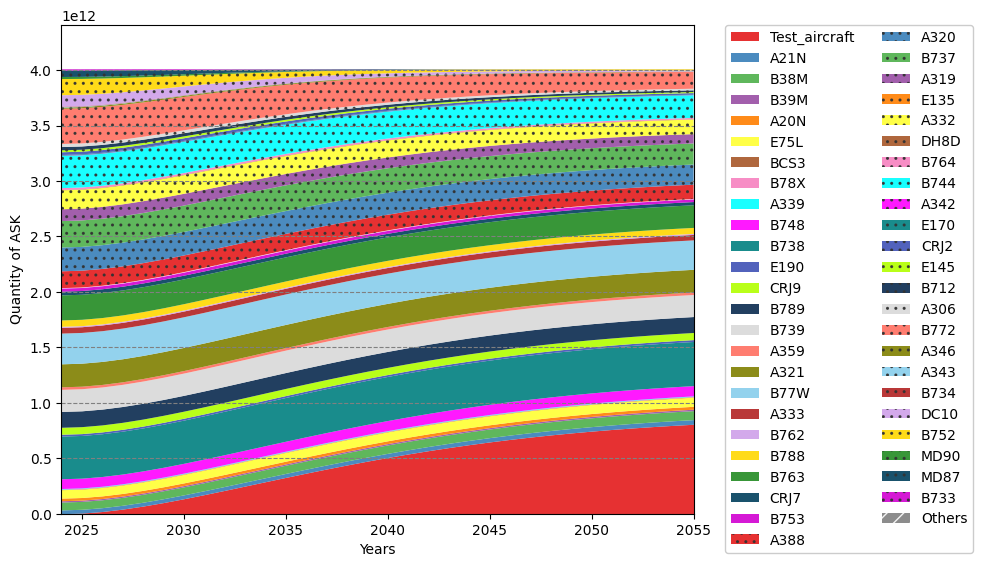

a remplir
0.0% 9.4% 18.8% 28.1% 37.5% 46.9% 56.3% 65.6% 75.0% 84.4% 93.8% 

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1400, 1000) to (1408, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [116]:
omegas_l = global_modelling.compute_fleet_assignment(
    vol_act, traffic_structures,
    alphas, betas, omegas_0, ranges,
    precision = 1e-5
)

global_modelling.observe_scenario(alphas, betas,ranges, omegas_l, types_names, traffic_structures, period_duration=period_duration, observation = 'ASK',
                     obs_sizes = obs_sizes, dic_fuel = dico_seymm, vals_fuel = fb_ini, period_ref = None,add_period = 2024, save_name = 'scenario_demo_omega', reso = 400,
                                  label_size_param = 1.8)
# global_modelling.observe_scenario(alphas, betas,ranges, omegas_l, types_names, traffic_structures, period_duration=period_duration, observation = 'Av_ac_seats',
#                      obs_sizes = obs_sizes, dic_fuel = dico_seymm, vals_fuel = fb_ini, period_ref = 0, save_name = 'scenario_light', reso = 150)
# global_modelling.observe_scenario(alphas, betas,ranges, omegas_l, types_names, traffic_structures, period_duration=period_duration, observation = 'FB',
#                      obs_sizes = obs_sizes, dic_fuel = dico_seymm, vals_fuel = fb_ini, period_ref = 0, save_name = 'scenario_light', reso = 150)

## Stats scénario interessantes

### Intensité énergétique

In [271]:
type_seats = dict(zip(modeled_aircraft['Aircraft Type Name'],modeled_aircraft['Est_avg_seats']))
type_e =  dict(zip(FB_seymm['ac_code_icao'], FB_seymm['reduced_fuel_a1']*3000+FB_seymm['reduced_fuel_a2']+FB_seymm['reduced_fuel_intercept']/3000))
modeled_aircraft_o = modeled_aircraft.copy()
modeled_aircraft_o['co2_g_ask'] = 1000*3.83*modeled_aircraft_o['Aircraft Type Name'].map(type_e)/modeled_aircraft_o['Aircraft Type Name'].map(type_seats)
modeled_aircraft_o.sort_values(by='co2_g_ask', inplace = True)
show(modeled_aircraft_o)

Loading ITables v2.6.2 from the internet... (need help?)


### Contrainte en range

In [616]:
obs_choice = 'Av_ac_seats' #'ASK' ou 'Av_ac_seats'
ds_name='bts'#BTS : 'bts', EUROCONTROL : 'ec'
n_choice = 100

if ds_name == 'bts' :
    traff_s = traff_1.copy() #cette version de 1990 à 2024
    traff_cond = traff_s[['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', obs_choice, obs_choice+'_conn_p','N_flights', 'Seats']].groupby(
        ['ADEP','ADES','Aircraft Type','Aircraft Type Name', 'Period', 'Distance_conn (km)', 'Weight', 'Seats_conn_p', obs_choice+'_conn_p']).sum().reset_index()
    df_training, c_table, existence_cache, ranges, connections = assignment_multilogit.data_formatting(traff_cond, n_ac= n_choice, seuils_f = 0.005, weight = True,
                                                                                                   obs = obs_choice, save_techn_carac = True, airports = False) #True seulement pour bts
mod_table = dict(zip(c_table['Aircraft Type Name'],c_table['Id_mod']))

modeled_aircraft = assignment_multilogit.correspondance_table(title_coeffs = 'logit_model_bts_ASK_35_5_1_9',title_tech = 'BTS_Av_ac_seats_100_35', 
                                                              obs_choice = 'Av_ac_seats')
modeled_aircraft.drop(columns='Av_ac_seats_weight', inplace = True)
modeled_aircraft.reset_index(inplace=True, drop = True)
seats_map = modeled_aircraft['Est_avg_seats'].to_dict()
ids_map = modeled_aircraft['Aircraft Type Name'].to_dict()
types_obs_list = list(modeled_aircraft['Aircraft Type Name'])
traff_s = traff_1[(traff_1['Aircraft Type Name'].isin(types_obs_list))]
traff_s['Av_ac_seats_w'] = traff_s['Av_ac_seats']*traff_s['Weight']

99.9% Av_ac_seatss selected.


#### Visualisation détaillée

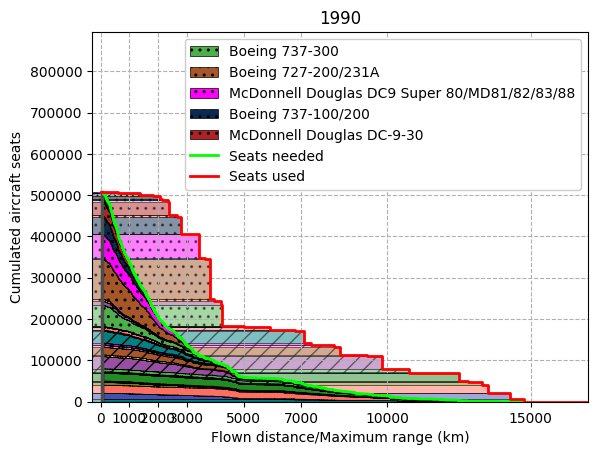

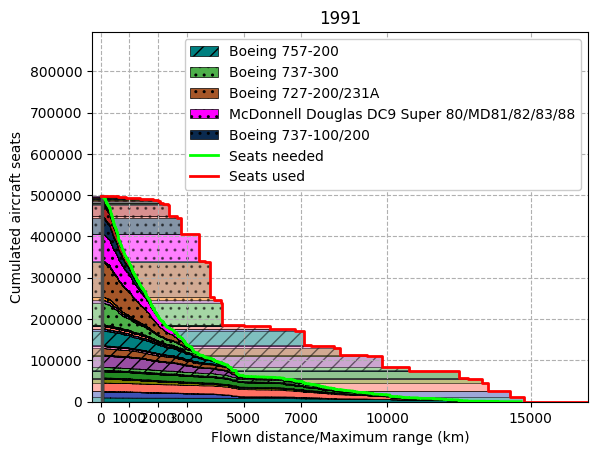

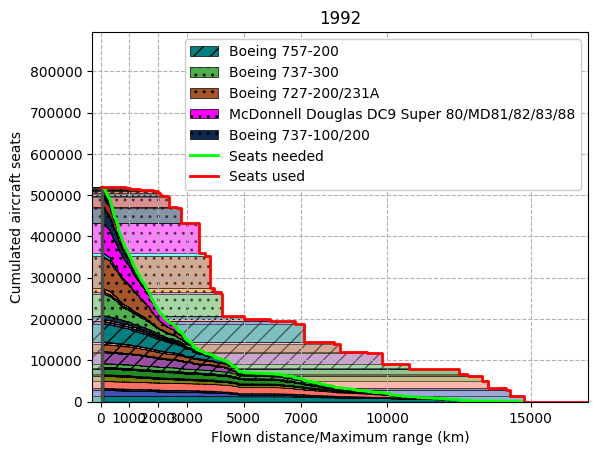

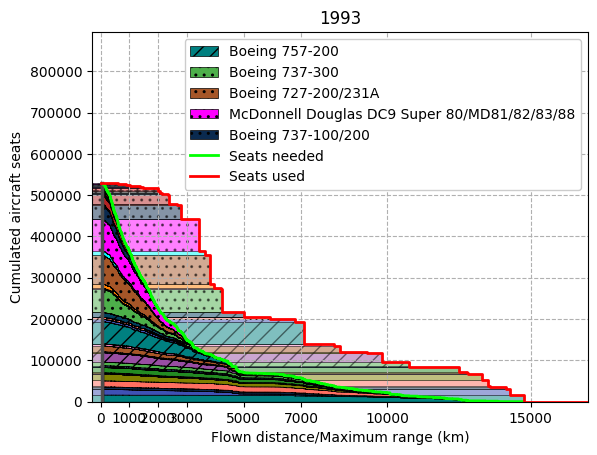

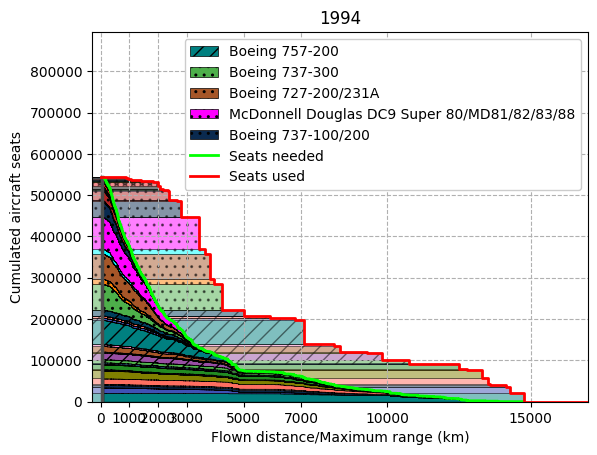

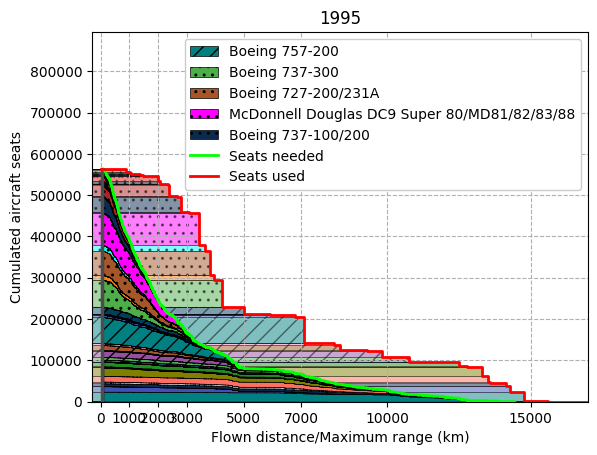

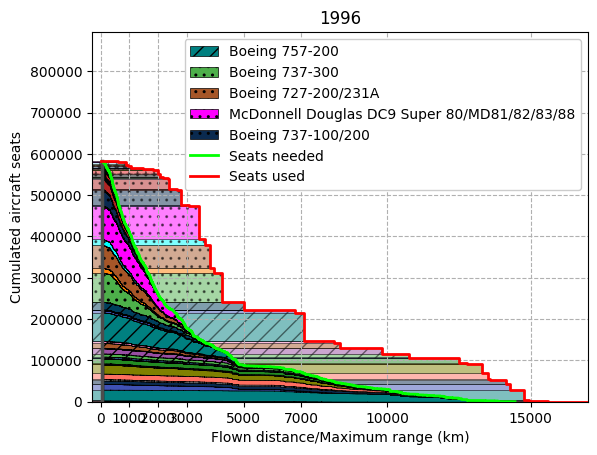

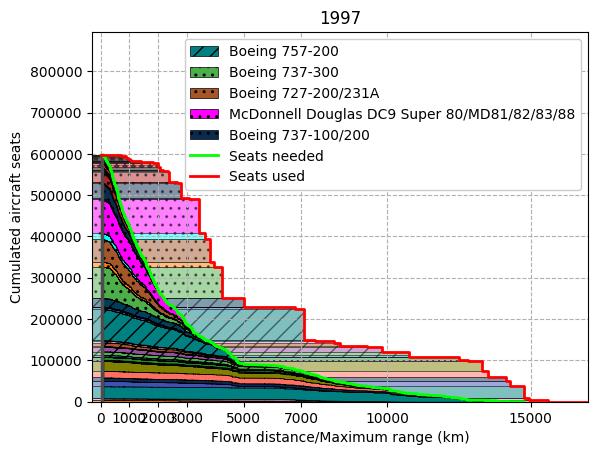

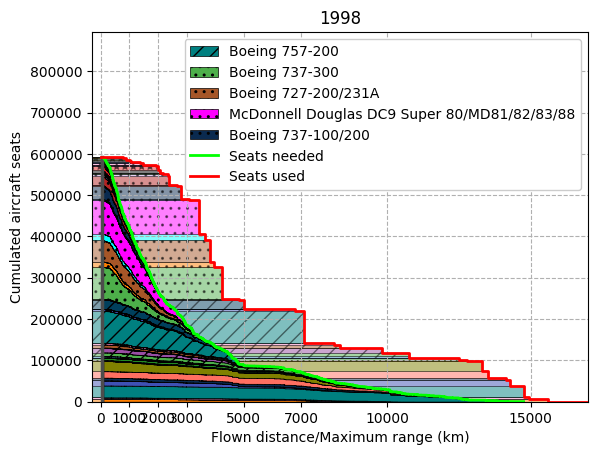

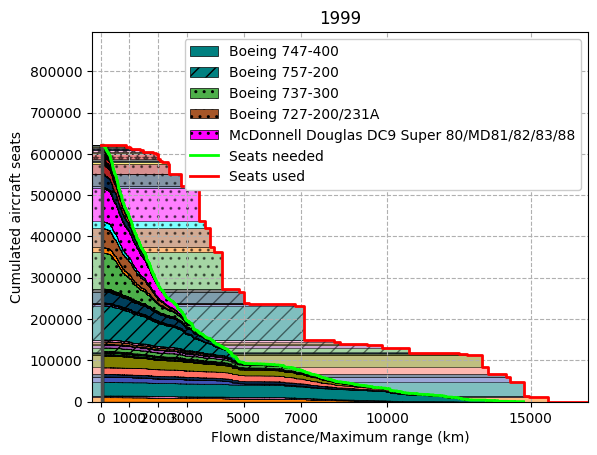

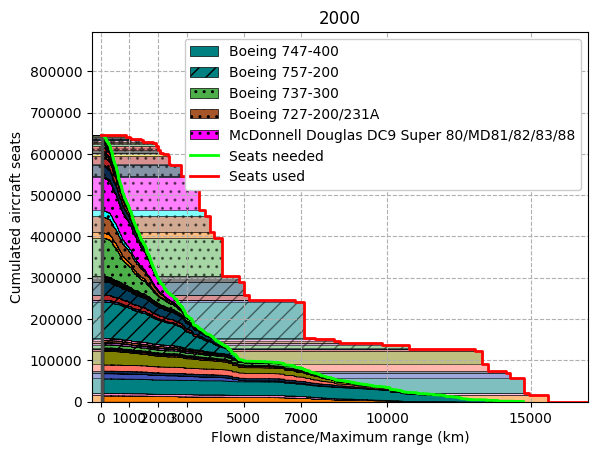

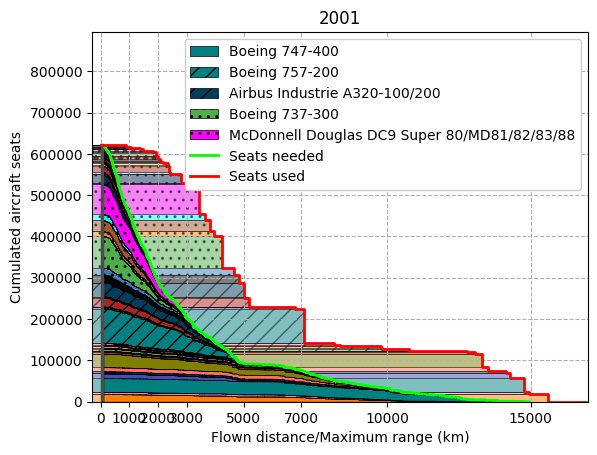

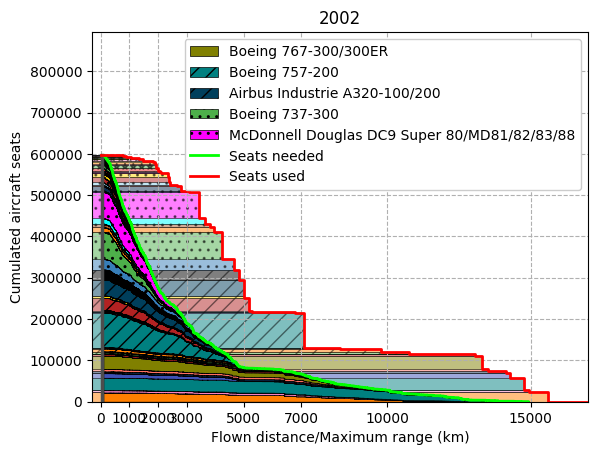

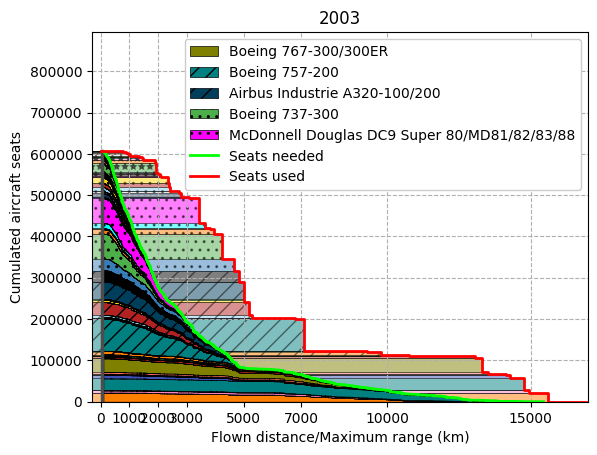

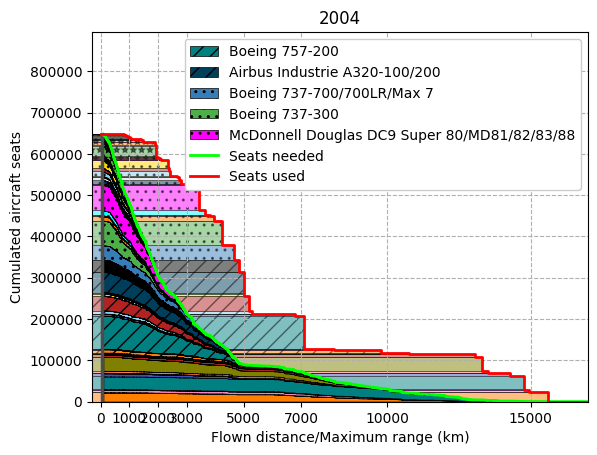

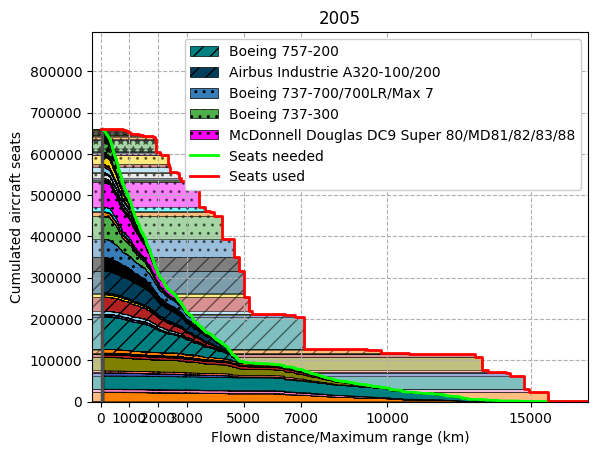

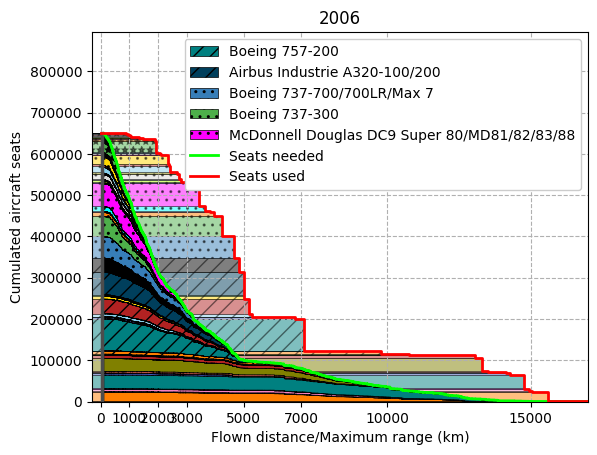

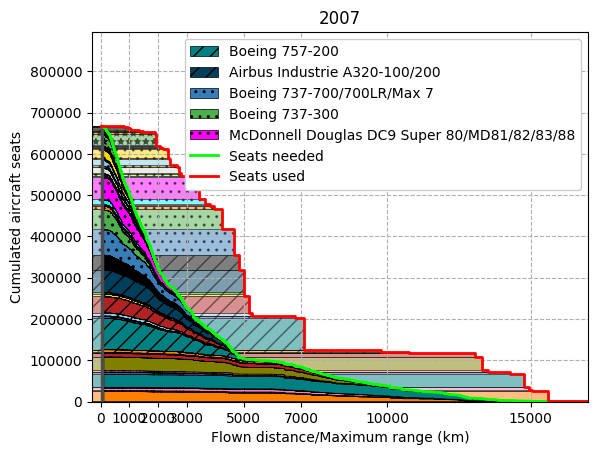

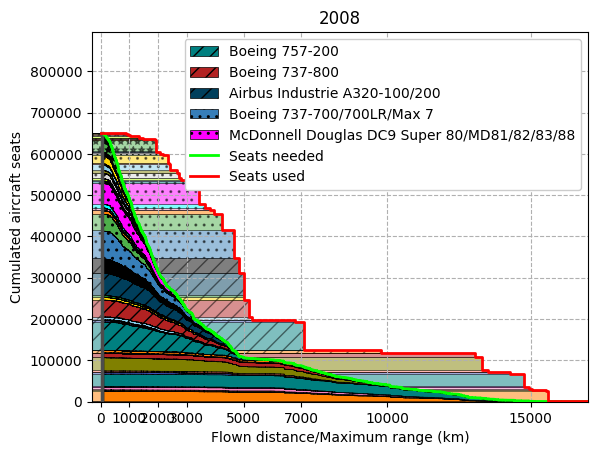

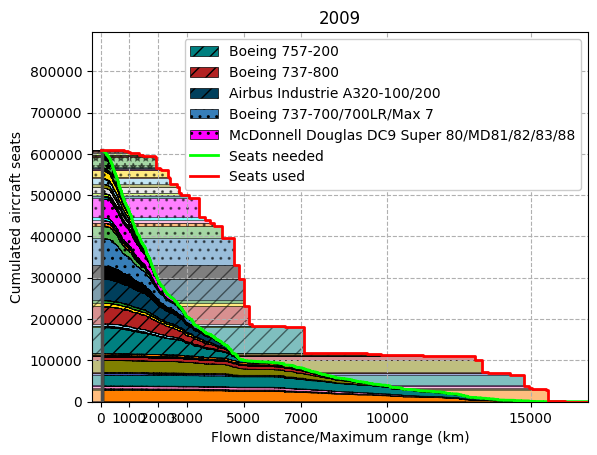

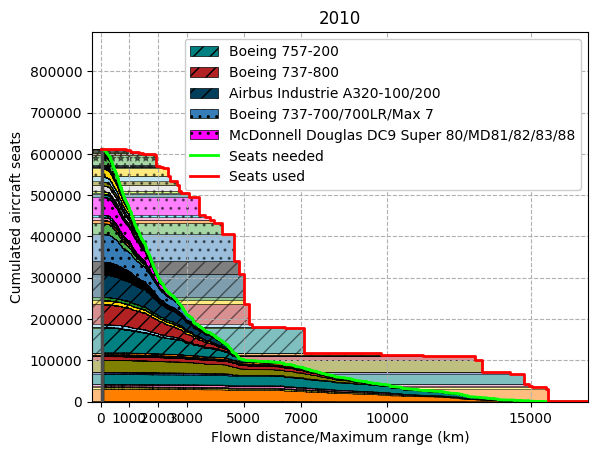

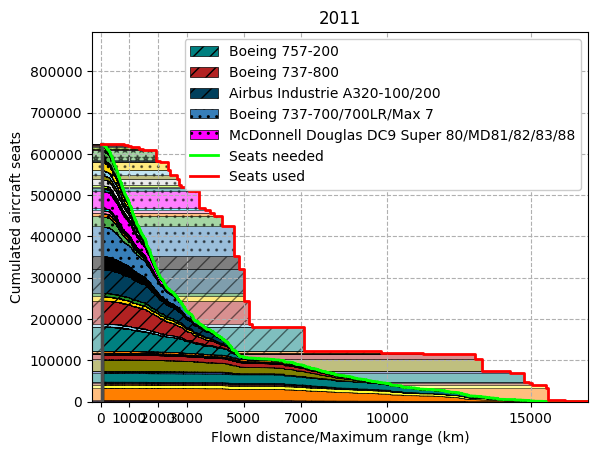

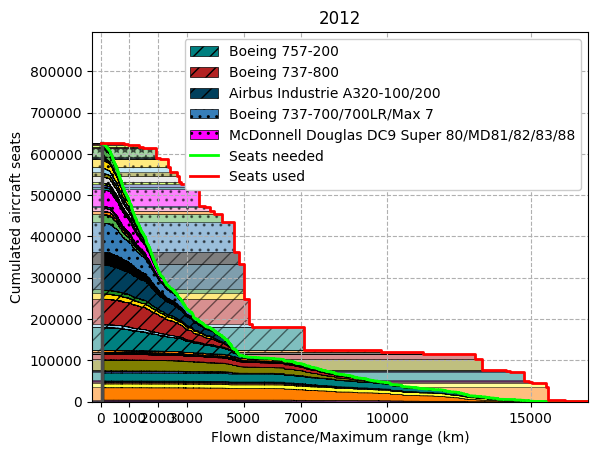

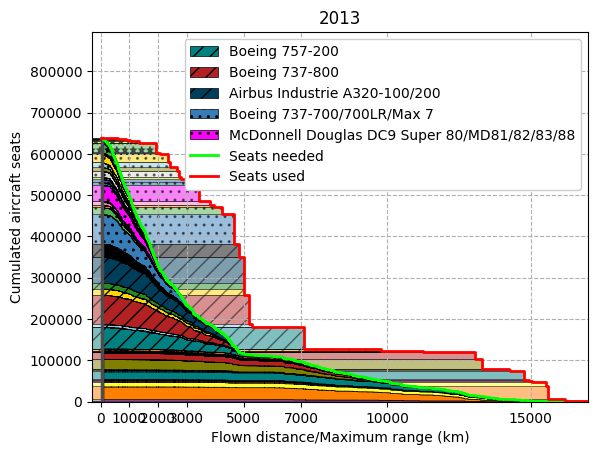

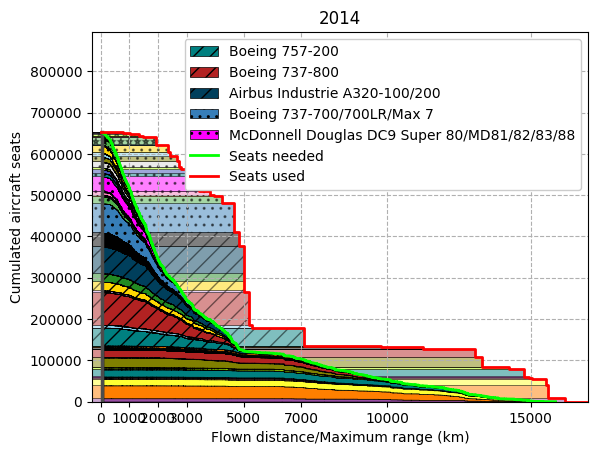

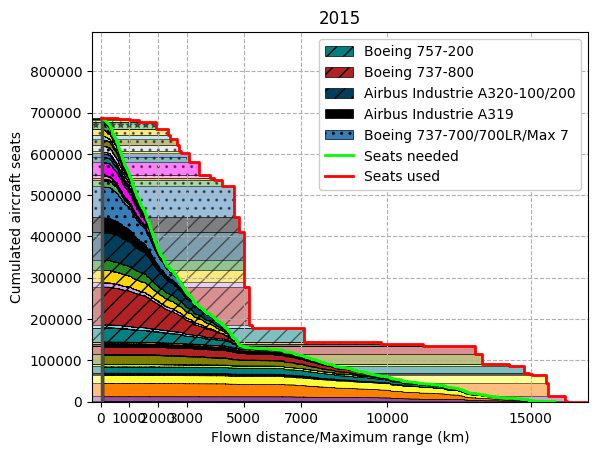

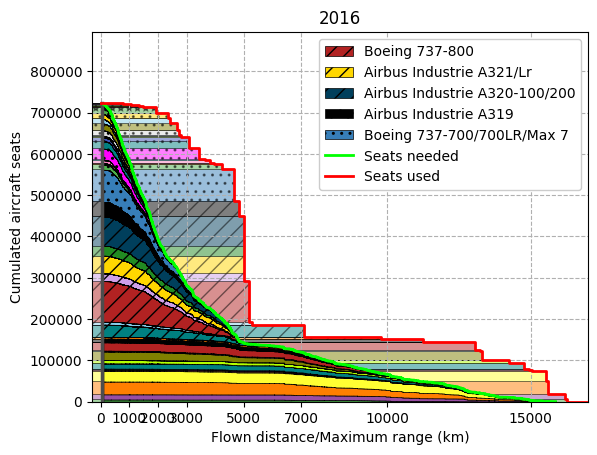

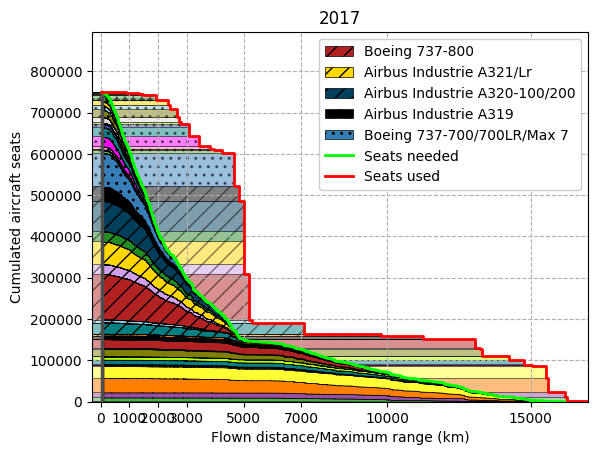

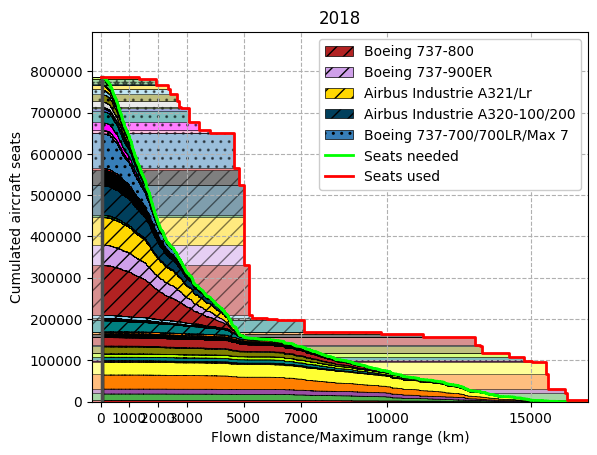

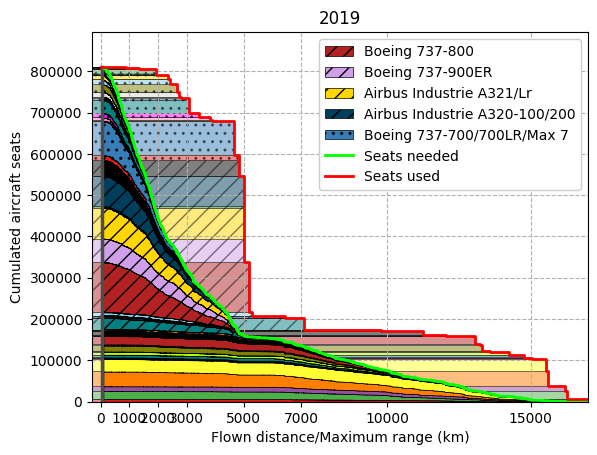

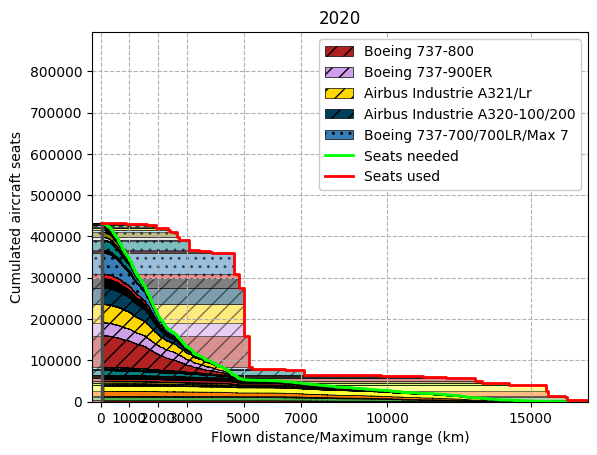

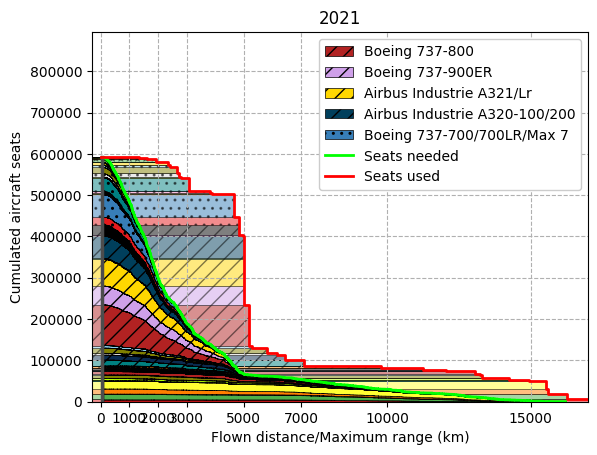

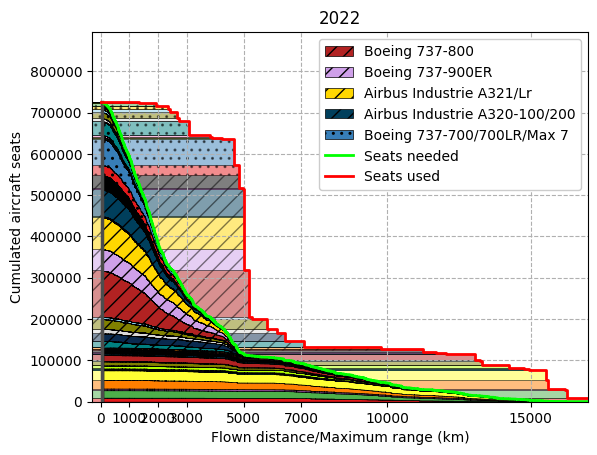

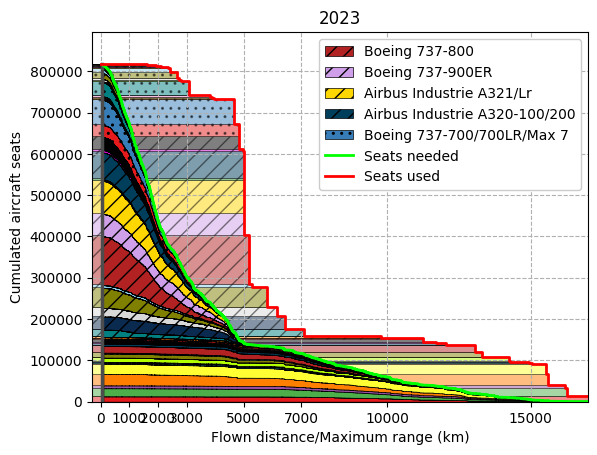

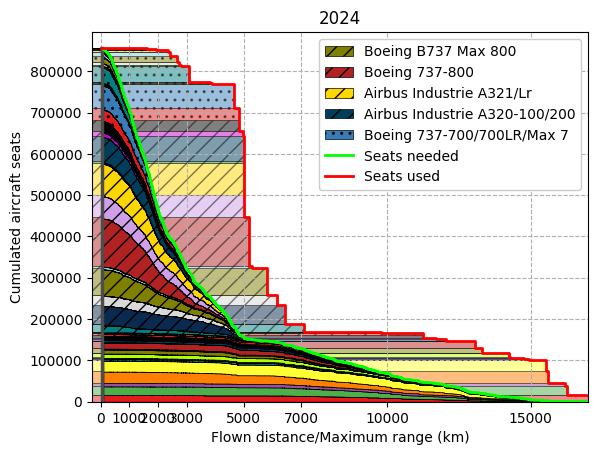

In [75]:
plt.close()
xticks = [0, 1000,2000,3000,5000,7000,10000,15000]
max_cap = 1.05*connections[connections['Period']==34]['Av_ac_seats_w_mod'].sum()
hatch_choice = [None,'//','..','**']

#pour focuser sur une compagnie
# operator_name = 'American Airlines Inc.'
# traff_1['Av_ac_seats_w'] = traff_1['Av_ac_seats'] *traff_1['Weight']
# df_training = traff_1[traff_1['Aircraft Operator Name']==operator_name].copy()
# df_training['Id_mod'] = df_training['Aircraft Type Name'].map(mod_table)
# df_training['Period'] -=1990 
# traff_s = traff_1[traff_1['Aircraft Operator Name']==operator_name].copy()
# connections = df_training[['Period','ADEP','ADES','Distance_conn (km)','Av_ac_seats_w']].groupby(
#     ['Period','ADEP','ADES','Distance_conn (km)']).sum().reset_index().rename(
#     columns = {'Av_ac_seats_w':'Av_ac_seats_w_mod'})

for t in range(1990, 2025):
    traff_t =traff_s[traff_s['Period']==t]
    L_types = traff_t[['Aircraft Type Name','Av_ac_seats_w']].groupby('Aircraft Type Name').sum().reset_index()
    modeled_aircraft_o = modeled_aircraft.copy()
    modeled_aircraft_o = modeled_aircraft_o.merge(L_types, left_on = 'Aircraft Type Name', right_on = 'Aircraft Type Name', how='left')
    modeled_aircraft_o = modeled_aircraft_o.fillna(0)
    modeled_aircraft_o.sort_values(by='Est_max_range', inplace = True, ascending = False)
    top_ac = list(modeled_aircraft_o.sort_values(by='Av_ac_seats_w', ascending = False)[:5].index)

    modeled_aircraft_o['Cap_cum'] = modeled_aircraft_o['Av_ac_seats_w'].cumsum()

    connections_t = connections[connections['Period']==t-1990]
    connections_t = connections_t.sort_values(by = 'Distance_conn (km)', ascending = False)
    connections_t['Cap_cum'] = connections_t['Av_ac_seats_w_mod'].cumsum()
    df_training_t = df_training[df_training['Period']==t-1990]
    df_training_t.sort_values(by='Distance_conn (km)', ascending = False, inplace =True)
    Cap_cum = list(modeled_aircraft_o['Cap_cum'])
    Cap_cum_e = [0]+Cap_cum
    Ac_ranges = list(modeled_aircraft_o['Est_max_range'])
    prev = 0
    for ac in range(len(Ac_ranges)):
        plt.fill_between([-300,Ac_ranges[ac]],Cap_cum_e[ac],Cap_cum[ac], zorder = 1, alpha = 0.5, color=vis_ref.colors_26[ac%25], linewidth = 0.5, hatch=hatch_choice[ac//25],edgecolor='black')
        df_training_ac_t = df_training_t.copy()
        df_training_ac_t['Cap_cum'] = prev
        df_training_ac_t['Av_ac_seats_w'] = df_training_ac_t['Av_ac_seats_w']*(df_training_ac_t['Id_mod']==mod_table[ids_map[modeled_aircraft_o.index[ac].astype(int)]])
        df_training_ac_t['Cap_cum'] += df_training_ac_t['Av_ac_seats_w'].cumsum()
        if modeled_aircraft_o.index[ac] in (top_ac):
            plt.fill_between(df_training_ac_t['Distance_conn (km)'],prev,df_training_ac_t['Cap_cum'], zorder = 2, alpha = 1, linewidth = 0.5,
                             label = ids_map[modeled_aircraft_o.index[ac]], color=vis_ref.colors_26[ac%25], hatch =hatch_choice[ac//25],edgecolor='black')
        else :
            plt.fill_between(df_training_ac_t['Distance_conn (km)'],prev,df_training_ac_t['Cap_cum'], zorder = 2, alpha = 1,  linewidth = 0.5,
                              color=vis_ref.colors_26[ac%25], hatch=hatch_choice[ac//25],edgecolor='black')
        prev = df_training_ac_t['Cap_cum']
    plt.step(connections_t['Distance_conn (km)'],np.array(connections_t['Cap_cum']),where='pre', label = 'Seats needed', linewidth = 2,color = 'lime', zorder = 3)
    plt.step(Ac_ranges+[0],np.array(Cap_cum+[Cap_cum[-1]]),where='pre', label = 'Seats used', linewidth = 2,color = 'red', zorder = 3)
    plt.plot([50,50],[0,Cap_cum[-1]], '0.3', linewidth = 2.5)
    plt.ylim(0,max_cap)
    plt.xlim(-300, 17000)
    plt.grid(linestyle='--')
    # plt.xscale('log')
    plt.ylabel('Cumulated aircraft seats')
    plt.xlabel('Flown distance/Maximum range (km)')
    plt.xticks(xticks, xticks)
    plt.legend(ncol = 1, framealpha = 1)
    plt.title(str(t), fontsize = 12)
    plt.savefig('figures/range_constraints/full_names_constraint_seats_'+str(t)+'.png', dpi=200)
    plt.show()
max_cap = 1.05*connections[connections['Period']==34]['Av_ac_seats_w_mod'].sum()

# traff_t =traff_s[traff_s['Period']==t]
# traff_t['ASK_w'] = traff_t['ASK']*traff_t['Weight']
# L_types = traff_t[['Aircraft Type Name','ASK_w']].groupby('Aircraft Type Name').sum().reset_index()
# modeled_aircraft_o = modeled_aircraft.copy()
# modeled_aircraft_o = modeled_aircraft_o.merge(L_types, left_on = 'Aircraft Type Name', right_on = 'Aircraft Type Name', how='left')
# modeled_aircraft_o = modeled_aircraft_o.fillna(0)
# modeled_aircraft_o.sort_values(by='Est_max_range', inplace = True, ascending = False)
# modeled_aircraft_o['Cap_cum'] = modeled_aircraft_o['ASK_w'].cumsum()

# connections_t = connections[connections['Period']==t-1990]
# connections_t = connections_t.sort_values(by = 'Distance_conn (km)', ascending = False)
# connections_t['ASK_w'] = connections_t['Seats_conn_p']*connections_t['Weight']*connections_t['Distance_conn (km)']
# connections_t['Cap_cum'] = connections_t['ASK_w'].cumsum()

# Cap_cum = list(modeled_aircraft_o['Cap_cum'])
# Cap_cum_e = [0]+Cap_cum
# Ac_ranges = list(modeled_aircraft_o['Est_max_range'])


#### Visualisation dynamique

In [617]:
matrix = df_training.pivot_table(
    index='Period',
    columns='Distance_conn (km)',
    values='Av_ac_seats_w',
    aggfunc='sum',
    fill_value=0
)
mat = matrix.values

traffic_structures = np.zeros((mat.shape[0],mat.shape[1],2))
traffic_structures[:,:,1] = mat
traffic_structures[:,:,0] = matrix.columns.values[None,:]

In [618]:
vol_act = df_training.pivot_table(
    index='Period',
    columns='Id_mod',
    values='Av_ac_seats_w',
    aggfunc='sum',
    fill_value=0
).sort_index(axis=0, ascending=True)\
 .sort_index(axis=1, ascending=True).values

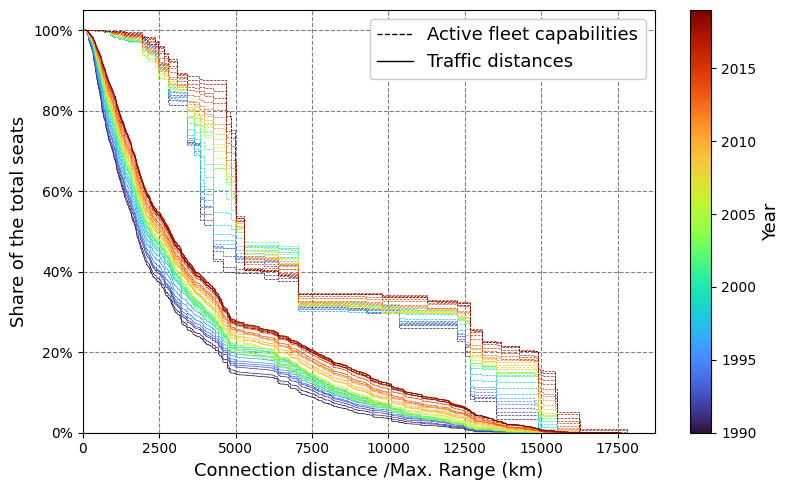

In [619]:
ac_ranges = np.array(list(modeled_aircraft['Est_max_range']))
fleet_analysis.constraint_plot(traffic_structures[:30],vol_act[:30],ac_ranges, title = 'BTS_historic', years = [1990,2019])


#### Propension de retrait

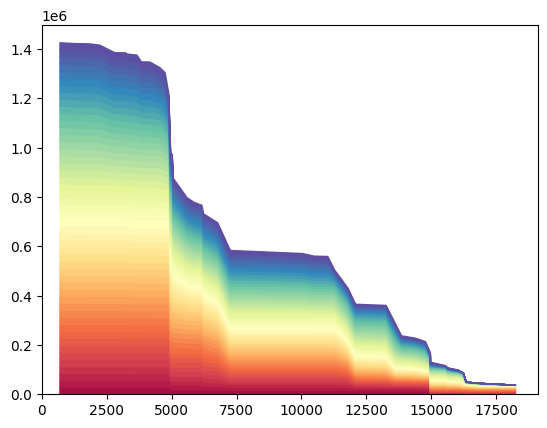

In [348]:
print('propension de retrait')

propensions_r = propensions[:52,:50]
obs_sizes_r = obs_sizes[:50]
ranges_r= ranges[:50]
seats_fleet = initial_fleet_r*obs_sizes_r[None,:]


fleet_obs_act_t, x_eq = fleet_content_modelling.fleet_content(0, 1, seats_fleet, propensions_r,
                                                                      0.05*seats_fleet.sum(), epsilon=1e-5, first=True)

x_prec = 0
for i in range(1,51):
    fleet_obs_act_t, x_eq = fleet_content_modelling.fleet_content(0, 1, seats_fleet, propensions_r,
                                                                      i/50*seats_fleet.sum(), epsilon=1e-5, first=True)
    fleet_obs_act_t_mod = fleet_obs_act_t.sum(axis=0)
    vis = pd.DataFrame({'Ranges':ranges_r, 'Vol':fleet_obs_act_t_mod})
    vis.sort_values(by ='Ranges', ascending = False, inplace = True)
    vis['Cum'] = vis['Vol'].cumsum()
    cmap = plt.get_cmap('Spectral')  # ou 'viridis', 'plasma', etc.
    color = cmap(i / 50)  # i normalisé entre 0 et 1
    plt.fill_between(vis['Ranges'],x_prec,vis['Cum'],  color=color)

    x_prec = vis['Cum']
plt.ylim(0)
plt.xlim(0)
plt.savefig('figures/range_constraints/iso_curves.pdf')
plt.show()


In [325]:
x_eq

9.293150289290027e-165

# Test Fuels burns

In [53]:
a = np.array([1,0])
np.diff(a)

array([-1])

In [31]:
resultat = list(set(a) - set(b))

In [32]:
resultat

[]